**Considering two things in glucose env only:**
1. Excretion profiles in outlier samples
2. tRNAChargingReactions; does the flux through these reactions (and thus synthesis of amino acids) vary?

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import scripts.EDA.data_prep2 as prep

In [3]:
data = pd.read_pickle(DATA/'ml_datasets_ARCHIVE/all_raw_samples.pkl')

## 1. Outlier secretion profiles

In [26]:
data['outliers_2'] = data['lipid_biomass_to_biomass'] / data['biomass_dilution']
data['outliers_2'] = data["outliers_2"].round(3)

deviating_rows = data[data["outliers_2"] != 0.134]


mask = (
    (deviating_rows['outlier'] != 1) &
    (deviating_rows['outliers_2'] > 0.135)
)

samples_to_update = deviating_rows.loc[mask, 'sample']

data.loc[data['sample'].isin(samples_to_update), 'outlier'] = 1


mask = (
    (deviating_rows['outlier'] != 1) &
    (deviating_rows['outliers_2'] > 0.135)
)

samples_to_update = deviating_rows.loc[mask, 'sample']

data.loc[data['sample'].isin(samples_to_update), 'outlier'] = 1

In [5]:
glc_data = data[data['source']=='glc']

glc_flux = pd.read_pickle('/triumvirate/home/celinaha/LO_sampling/optimal_runs/optimal_EX_glc__D_e_EX_nh4_e.pkl')

In [6]:
glc_out = glc_data.loc[glc_data['outlier']==1, "sample"]
glc_normal = glc_data.loc[glc_data['outlier']==0, "sample"]

In [7]:
glc_outliers = glc_data[glc_data["outlier"]==1]

**Exchange reactions:**

In [22]:
glc_ex = glc_flux[glc_flux["reaction"].str.startswith("EX_", na=False)].copy()
glc_ex.drop(columns='flux', inplace=True)

glc_ex.to_csv('ex_rxns.csv', index=False)

In [ ]:
glc_samples = prep.get_samples(path='/triumvirate/home/celinaha/LHS_sampling/lhs_glc/results/flux')
# glc = prep.merge_samples(glc_samples, '/triumvirate/home/celinaha/thesis_files/ex_rxns.csv', substrate='glc')
glc = prep.merge_samples(glc_samples, '/triumvirate/home/celinaha/thesis_files/files/bm_rxns_template.csv', substrate='glc')

In [62]:
bm_glc = glc.drop(columns="biomass_type").set_index("reaction").T

In [27]:
bm_data = pd.read_pickle("/triumvirate/home/celinaha/thesis_files/data/bm_all_samples.pkl")

bm_data = bm_data.drop(columns="biomass_type").set_index("reaction").T

In [116]:
lipid_mod = [col for col in bm_data.columns if "lipid_modification" in col]
# lipid_mod = [col for col in bm_glc.columns if "lipid_modification" in col]

lipid_non_zero = []

for i in lipid_mod:
    col = bm_data[i]

    if col.sum() != 0:
        lipid_non_zero.append(i)

In [ ]:
len(lipid_non_zero) #all samples in total

41

In [ ]:
unique_lipo_proteins = []

for i in lipid_non_zero:
    prot = i.split('_', 1)[0]

    unique_lipo_proteins.append(prot)
    # for j in unique_lipo_proteins:

    #     if prot != j:
    #         unique_lipo_proteins.append(prot)

In [ ]:
unique_lipo_proteins = list(set(unique_lipo_proteins))

unique_lipo_proteins

['b1677', 'b2595', 'b1209', 'b2512', 'b2477', 'b1193', 'b0572', 'b2617']

In [86]:
all_lipo_proteins = []

for i in lipid_mod:
    prot = i.split('_', 1)[0]

    all_lipo_proteins.append(prot)

all_lipo_proteins = list(set(all_lipo_proteins))
all_lipo_proteins

['b0197',
 'b2701',
 'b1677',
 'b3265',
 'b0572',
 'b2595',
 'b1209',
 'b2512',
 'b2477',
 'b1193',
 'b2813',
 'b0463',
 'b2963',
 'b2617']

In [65]:
len(lipid_non_zero) #glc samples

18

In [29]:
# Set all lactose outliers to 0
data.loc[data['source'] == 'lcts', 'outlier'] = 0

# Set the two specific samples to 1
data.loc[data['sample'].isin(['lcts_sample_690', 'lcts_sample_757']),'outlier'] = 1

In [30]:
bm_data['source'] = data['source'].tolist()

**checking which deviations that show up (same y-scale)**

In [103]:
lipid_mod = [col for col in bm_data.columns if "lipid_modification" in col]

lipid_large_mag = []

for i in lipid_mod:
    col = bm_data[i]

    if col.sum() > 0.02:
        lipid_large_mag.append(i)
        print(i, col.sum())

lipid_large_mag = list(set(lipid_large_mag))
lipid_large_mag      

b1677_lipid_modification_pg120_p_pe160 7.801789065752509
b1677_lipid_modification_pg141_p_pe160 0.023946808347467593
b1677_lipid_modification_pg181_p_pe160 0.19115391440463064
b1677_lipid_modification_pg180_p_pe160 0.22212048385763167


['b1677_lipid_modification_pg180_p_pe160',
 'b1677_lipid_modification_pg181_p_pe160',
 'b1677_lipid_modification_pg141_p_pe160',
 'b1677_lipid_modification_pg120_p_pe160']

In [110]:
counts = (
    bm_data
    .groupby("source")[lipid_large_mag]
    .apply(lambda x: (x != 0).sum())
    .reset_index()
)

counts

reaction,source,b1677_lipid_modification_pg180_p_pe160,b1677_lipid_modification_pg181_p_pe160,b1677_lipid_modification_pg141_p_pe160,b1677_lipid_modification_pg120_p_pe160
0,ac,42,0,1,440
1,arg_ac,51,7,3,522
2,arg_glc,2,9,0,656
3,arg_glyc,4,4,0,645
4,glc,9,0,0,692
5,glyc,9,0,2,568
6,lcts,2,0,0,784
7,nh4_ac,42,21,6,222
8,nh4_glc,17,28,0,640
9,no3_ac,0,1,0,32


In [31]:
bm_data["outlier"] = data["outlier"].tolist()

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
color_map = sns.color_palette("GnBu", as_cmap=True)

In [27]:
bm_data["translation_b0720"]

glc_sample_0           3.558155e-08
glc_sample_1           2.322664e-06
glc_sample_2           1.995353e-05
glc_sample_3           7.015443e-06
glc_sample_4           2.128728e-06
                           ...     
no3_glyc_sample_591    2.019405e-05
no3_glyc_sample_592    6.911479e-06
no3_glyc_sample_593    1.205004e-05
no3_glyc_sample_594    1.308400e-05
no3_glyc_sample_595    3.132778e-05
Name: translation_b0720, Length: 7257, dtype: float64

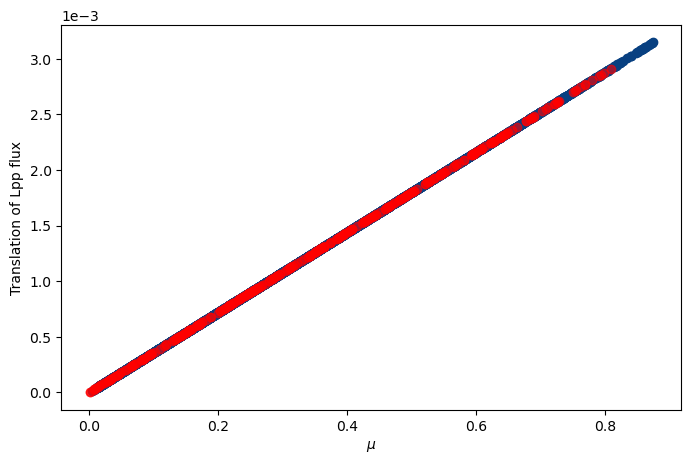

In [23]:
outliers_all = bm_data.loc[bm_data.index, 'outlier'] == 1

plt.figure(figsize=(8,5))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')
plt.scatter(x=bm_data["biomass_dilution"][~outliers_all], y=bm_data["translation_b1677"][~outliers_all], color=color_map(1.0))
plt.scatter(x=bm_data["biomass_dilution"][outliers_all], y=bm_data["translation_b1677"][outliers_all], alpha=0.6, color='red')

plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xlabel(r"$\mu$")
plt.ylabel("Translation of Lpp flux")
# plt.xlabel("PG 12:0 modification flux")

plt.show()

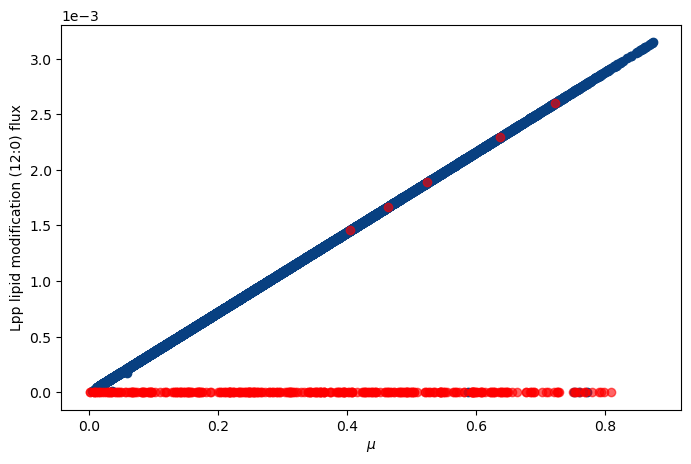

In [33]:
outliers_all = bm_data.loc[bm_data.index, 'outlier'] == 1

plt.figure(figsize=(8,5))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')
plt.scatter(x=bm_data["biomass_dilution"][~outliers_all], y=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], color=color_map(1.0))
plt.scatter(x=bm_data["biomass_dilution"][outliers_all], y=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], alpha=0.6, color='red')

plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xlabel(r"$\mu$")
plt.ylabel("Lpp lipid modification (12:0) flux")
# plt.xlabel("PG 12:0 modification flux")

plt.show()

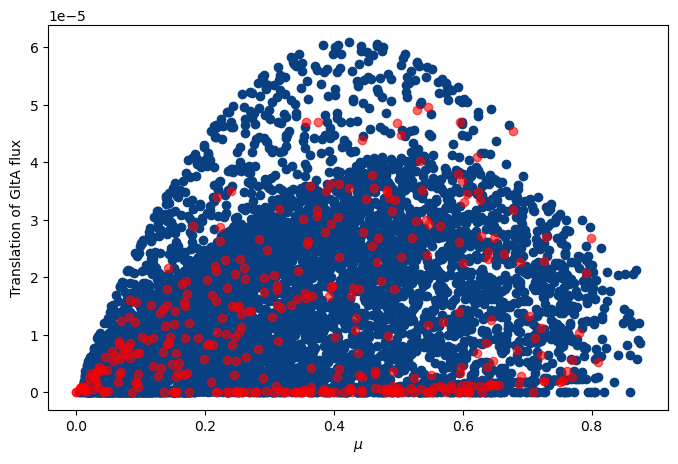

In [59]:
gltA = bm_data["translation_b0720"]
mu = bm_data["biomass_dilution"]

outliers_all = bm_data.loc[bm_data.index, 'outlier'] == 1

plt.figure(figsize=(8,5))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')
plt.scatter(x=bm_data["biomass_dilution"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
plt.scatter(x=bm_data["biomass_dilution"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')


plt.xlabel(r"$\mu$")
plt.ylabel("Translation of GltA flux")
# plt.xlabel("PG 12:0 modification flux")

plt.show()

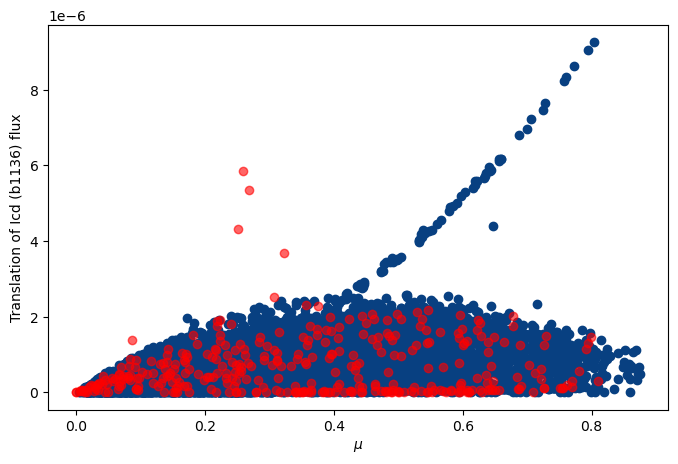

In [49]:
outliers_all = bm_data.loc[bm_data.index, 'outlier'] == 1

plt.figure(figsize=(8,5))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')
plt.scatter(x=bm_data["biomass_dilution"][~outliers_all], y=bm_data["translation_b1136"][~outliers_all], color=color_map(1.0))
plt.scatter(x=bm_data["biomass_dilution"][outliers_all], y=bm_data["translation_b1136"][outliers_all], alpha=0.6, color='red')


plt.xlabel(r"$\mu$")
plt.ylabel("Translation of Icd (b1136) flux")
# plt.xlabel("PG 12:0 modification flux")

plt.show()

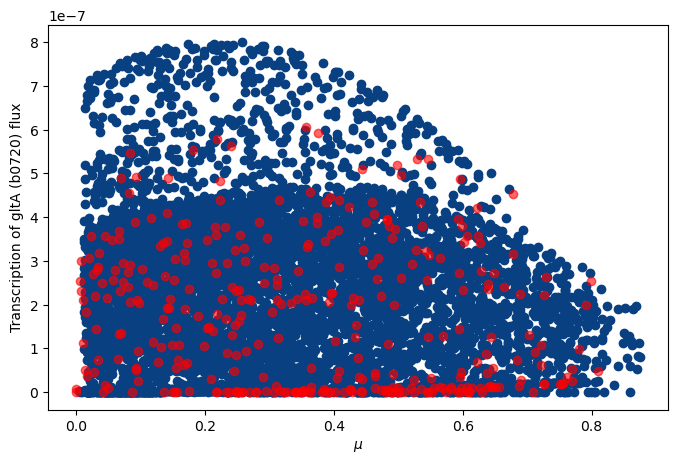

In [65]:
outliers_all = bm_data.loc[bm_data.index, 'outlier'] == 1

plt.figure(figsize=(8,5))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')
plt.scatter(x=bm_data["biomass_dilution"][~outliers_all], y=bm_data["transcription_TU00416_from_RpoD_mono"][~outliers_all], color=color_map(1.0))
plt.scatter(x=bm_data["biomass_dilution"][outliers_all], y=bm_data["transcription_TU00416_from_RpoD_mono"][outliers_all], alpha=0.6, color='red')


plt.xlabel(r"$\mu$")
plt.ylabel("Transcription of gltA (b0720) flux")
# plt.xlabel("EX_o2_e flux")

plt.show()

In [78]:
# lcts = data[data["source"]=="lcts"]
bm_data["source"] = data["source"].tolist()
glc = bm_data[bm_data["source"]=="glc"]
glc_out = glc[glc["outlier"]==1]

In [87]:
glc_out["EX_o2_e"]

glc_sample_152    -1.596374
glc_sample_269    -4.048472
glc_sample_277   -11.690847
glc_sample_285    -3.087152
glc_sample_288    -7.068314
glc_sample_334   -33.382845
glc_sample_373    -7.442252
glc_sample_415    -3.915147
glc_sample_436    -2.321342
glc_sample_563   -10.663566
glc_sample_572    -6.962712
glc_sample_617    -7.773468
glc_sample_642    -5.925201
glc_sample_679    -2.071203
Name: EX_o2_e, dtype: float64

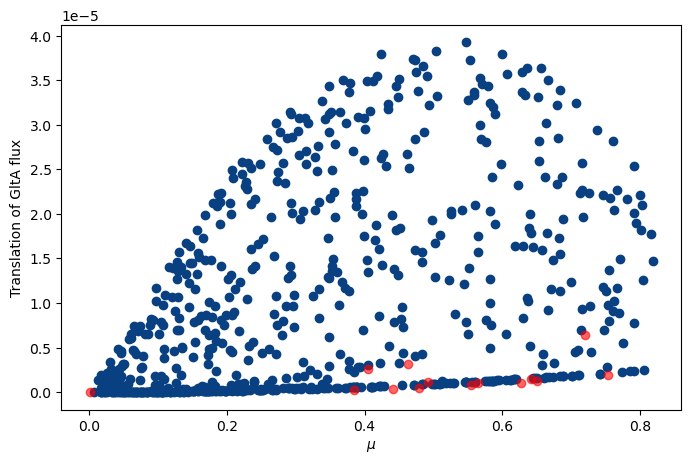

In [82]:
outliers_glc = glc.loc[glc.index, 'outlier'] == 1

plt.figure(figsize=(8,5))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')
plt.scatter(x=glc["biomass_dilution"][~outliers_all], y=glc["translation_b0720"][~outliers_all], color=color_map(1.0))
plt.scatter(x=glc["biomass_dilution"][outliers_all], y=glc["translation_b0720"][outliers_all], alpha=0.6, color='red')


plt.xlabel(r"$\mu$")
plt.ylabel("Translation of GltA flux")
# plt.xlabel("PG 12:0 modification flux")

plt.show()

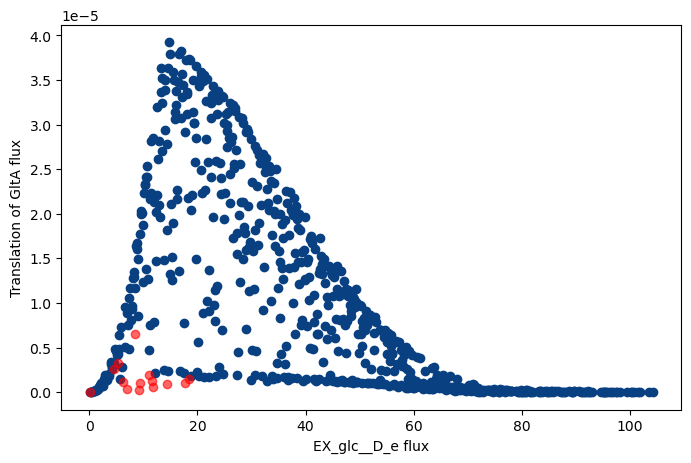

In [84]:
plt.figure(figsize=(8,5))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][~outliers_all], y=bm_data["translation_b0720"][~outliers_all], color=color_map(1.0))
# plt.scatter(x=bm_data["b1677_lipid_modification_pg120_p_pe160"][outliers_all], y=bm_data["translation_b0720"][outliers_all], alpha=0.6, color='red')
plt.scatter(x=-glc["EX_glc__D_e"][~outliers_all], y=glc["translation_b0720"][~outliers_all], color=color_map(1.0))
plt.scatter(x=-glc["EX_glc__D_e"][outliers_all], y=glc["translation_b0720"][outliers_all], alpha=0.6, color='red')


# plt.xlabel(r"$\mu$")
plt.ylabel("Translation of GltA flux")
plt.xlabel("EX_glc__D_e flux")

plt.show()

In [79]:
glc_out["translation_b0720"]

glc_sample_152    2.608353e-07
glc_sample_269    3.342742e-07
glc_sample_277    6.463352e-06
glc_sample_285    8.599070e-07
glc_sample_288    2.611060e-06
glc_sample_334    1.629168e-10
glc_sample_373    1.006354e-06
glc_sample_415    1.495241e-06
glc_sample_436    5.203763e-07
glc_sample_563    1.922220e-06
glc_sample_572    1.244077e-06
glc_sample_617    3.220702e-06
glc_sample_642    1.146962e-06
glc_sample_679    1.030874e-06
Name: translation_b0720, dtype: float64

In [ ]:
outlier = bm_data[bm_data['outlier']==1]

In [93]:
# # bm_data['outlier'] = data['outlier'].tolist()
# bm_glc['outlier'] = glc_data['outlier'].tolist()

# # outlier = bm_data[bm_data['outlier'] == 1]
# # normal = bm_data[bm_data['outlier'] == 0]

# outlier = bm_glc[bm_glc['outlier'] == 1]
# normal = bm_glc[bm_glc['outlier'] == 0]

# for i in lipid_non_zero:
#     plt.figure(figsize=(5, 5))

#     plt.scatter(
#         normal["biomass_dilution"],
#         normal[i],
#         color="C0",      # default blue
#         label="Normal"
#     )

#     plt.scatter(
#         outlier["biomass_dilution"],
#         outlier[i],
#         color="red",
#         label="Outlier"
#     )

#     plt.title(i)
#     plt.xlabel("biomass_dilution")
#     plt.ylabel(i)
#     plt.legend()
#     plt.show()

In [111]:
# for i in lipid_non_zero:
#     plt.figure(figsize=(5, 5))

#     plt.scatter(
#         -normal["EX_glc__D_e"],
#         normal[i],
#         color="C0",      # default blue
#         label="Normal"
#     )

#     plt.scatter(
#         -outlier["EX_glc__D_e"],
#         outlier[i],
#         color="red",
#         label="Outlier"
#     )

#     plt.title(i)
#     plt.xlabel("EX_glc__D_e")
#     plt.ylabel(i)
#     plt.legend()
#     plt.show()

In [27]:
sec = glc.set_index("reaction").T
sec = sec.loc[:, (sec > 0).any(axis=0)]

In [28]:
sec_outliers = sec.loc[glc_out]
sec_normal = sec.loc[glc_normal]

In [57]:
sec_normal.describe().T

,count,mean,std,min,25%,50%,75%,max
reaction,,,,,,,,
EX_12ppd__R_e,689.0,1.716599e+00,5.417640e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.405459e+01
EX_5mtr_e,689.0,5.138885e-05,4.539530e-05,4.537892e-07,1.498523e-05,3.598704e-05,8.069308e-05,1.725457e-04
EX_ac_e,689.0,2.128985e-01,1.138777e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.335664e+01
EX_acald_e,689.0,1.559110e-05,2.201770e-05,0.000000e+00,0.000000e+00,5.122675e-06,2.301925e-05,9.032359e-05
EX_co2_e,689.0,3.099354e+01,3.145602e+01,6.734704e-02,2.217883e+00,2.107307e+01,5.314763e+01,1.076814e+02
EX_dha_e,689.0,4.229368e+01,3.314744e+01,0.000000e+00,1.583963e+01,4.009377e+01,6.249945e+01,1.425733e+02
EX_eca4colipa_e,689.0,2.184088e-27,5.732970e-26,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.504836e-24
EX_enter_e,689.0,5.628914e-28,1.477523e-26,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.878322e-25
EX_etoh_e,689.0,2.458646e-03,6.442987e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.691211e+00


In [56]:
sec_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
reaction,,,,,,,,
EX_12ppd__R_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_5mtr_e,14.0,6.396631e-05,3.835399e-05,1.833298e-08,3.737107e-05,5.910966e-05,8.903326e-05,1.333182e-04
EX_ac_e,14.0,7.170484e+00,6.133843e+00,0.000000e+00,1.023363e+00,7.577971e+00,1.124831e+01,1.748323e+01
EX_acald_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_co2_e,14.0,6.165506e+00,5.913299e+00,8.817323e-02,2.836324e-01,6.205876e+00,1.111908e+01,1.602023e+01
EX_dha_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_eca4colipa_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_enter_e,14.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_etoh_e,14.0,2.088753e+00,3.496102e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.993700e+00,1.002031e+01


In [138]:
sec.columns

sec["biomass_dilution"] = glc_data["biomass_dilution"].tolist()

In [200]:
sec.columns

Index(['EX_12ppd__R_e', 'EX_5mtr_e', 'EX_ac_e', 'EX_acald_e', 'EX_co2_e',
       'EX_dha_e', 'EX_eca4colipa_e', 'EX_enter_e', 'EX_etoh_e', 'EX_fe3_e',
       'EX_for_e', 'EX_glyc__R_e', 'EX_glyclt_e', 'EX_h_e', 'EX_h2o_e',
       'EX_lac__D_e', 'EX_lipa_e', 'EX_meoh_e', 'EX_pheme_e', 'EX_pyr_e',
       'EX_succ_e', 'biomass_dilution'],
      dtype='object', name='reaction')

In [117]:
sec_outliers["o2_e_shadow"] = glc_outliers["o2_e_shadow"].tolist()
sec_outliers["source_shadow"] = glc_outliers["source_shadow"].tolist()
sec_outliers["alpha"] = - (sec_outliers["source_shadow"]/sec_outliers["o2_e_shadow"])

sec_outliers["biomass_dilution"] = glc_outliers["biomass_dilution"].tolist()

In [211]:
sec_prof = sec_outliers[["biomass_dilution", "o2_e_shadow", "source_shadow", "alpha", 'EX_5mtr_e', 'EX_ac_e','EX_etoh_e',
       'EX_for_e', 'EX_glyclt_e', "EX_meoh_e"]]

sec_prof.sort_values(by="alpha", ascending=False)

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_5mtr_e,EX_ac_e,EX_etoh_e,EX_for_e,EX_glyclt_e,EX_meoh_e
glc_sample_334,0.000520,7.366932e-08,-0.000692,9389.309800,1.833298e-08,0.000000,0.000000,0.000000,0.000000,2.120647e-13
glc_sample_679,0.564255,-8.584021e-04,-0.000305,-0.355722,8.162992e-05,15.664559,10.020313,29.417622,0.000377,2.497115e-07
glc_sample_415,0.642172,-7.227430e-04,-0.000272,-0.376391,1.120391e-04,17.483226,8.952316,29.588104,0.000430,3.234396e-07
glc_sample_285,0.555374,-7.966844e-04,-0.000331,-0.415593,6.806318e-05,13.585332,4.933452,23.311299,0.000372,2.419130e-07
glc_sample_152,0.385353,-9.936895e-04,-0.000434,-0.436906,2.431259e-05,8.455025,2.017283,15.474534,0.000258,1.164666e-07
glc_sample_436,0.478870,-8.627490e-04,-0.000384,-0.444529,4.369411e-05,11.064913,3.319172,19.586711,0.000320,1.798548e-07
glc_sample_563,0.753315,-6.402248e-04,-0.000288,-0.449702,1.333182e-04,8.951878,0.000000,0.401266,0.000504,4.450878e-07
glc_sample_572,0.650382,-7.295642e-04,-0.000379,-0.519592,9.150105e-05,11.309438,0.000000,11.998711,0.000435,3.317624e-07
glc_sample_373,0.626846,-7.500258e-04,-0.000401,-0.534313,7.431632e-05,6.700918,0.000000,1.767519,0.000419,3.081847e-07
glc_sample_269,0.441987,-9.131616e-04,-0.000572,-0.626517,2.851162e-05,4.866028,0.000000,3.981497,0.000296,1.532164e-07


In [192]:
sec.columns

Index(['EX_12ppd__R_e', 'EX_5mtr_e', 'EX_ac_e', 'EX_acald_e', 'EX_co2_e',
       'EX_dha_e', 'EX_eca4colipa_e', 'EX_enter_e', 'EX_etoh_e', 'EX_fe3_e',
       'EX_for_e', 'EX_glyc__R_e', 'EX_glyclt_e', 'EX_h_e', 'EX_h2o_e',
       'EX_lac__D_e', 'EX_lipa_e', 'EX_meoh_e', 'EX_pheme_e', 'EX_pyr_e',
       'EX_succ_e', 'biomass_dilution'],
      dtype='object', name='reaction')

In [ ]:
sec_prof["EX_glc__D_e"] = glc_outliers["EX_glc__D_e"].tolist()
sec_prof["EX_o2_e"] = glc_outliers["EX_o2_e"].tolist()
sec_prof["EX_nh4_e"] = glc_outliers["EX_nh4_e"].tolist()

In [198]:
sec_prof[["biomass_dilution", "o2_e_shadow", "source_shadow", "alpha", "EX_o2_e", "EX_glc__D_e", "EX_nh4_e", 'EX_etoh_e']]

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_o2_e,EX_glc__D_e,EX_nh4_e,EX_etoh_e
glc_sample_152,0.385353,-9.936895e-04,-0.000434,-0.436906,-1.596374,-9.200463,-2.341014,2.017283
glc_sample_269,0.441987,-9.131616e-04,-0.000572,-0.626517,-4.048472,-7.049585,-2.613104,0.000000
glc_sample_277,0.720808,-6.929262e-04,-0.000901,-1.300687,-11.690847,-8.470784,-6.426609,0.000000
glc_sample_285,0.555374,-7.966844e-04,-0.000331,-0.415593,-3.087152,-14.364875,-4.730991,4.933452
glc_sample_288,0.404950,-1.015586e-02,-0.057792,-5.690486,-7.068314,-4.571650,-3.734376,0.000000
glc_sample_334,0.000520,7.366932e-08,-0.000692,9389.309800,-33.382845,-0.054239,-0.010898,0.000000
glc_sample_373,0.626846,-7.500258e-04,-0.000401,-0.534313,-7.442252,-9.348580,-4.926492,0.000000
glc_sample_415,0.642172,-7.227430e-04,-0.000272,-0.376391,-3.915147,-18.514742,-6.798350,8.952316
glc_sample_436,0.478870,-8.627490e-04,-0.000384,-0.444529,-2.321342,-11.868519,-3.491867,3.319172
glc_sample_563,0.753315,-6.402248e-04,-0.000288,-0.449702,-10.663566,-10.978559,-7.431143,0.000000


In [205]:
sec_alpha = sec.copy()
sec_alpha["o2_e_shadow"] = glc_data["o2_e_shadow"].tolist()
sec_alpha["source_shadow"] = glc_data["source_shadow"].tolist()

sec_alpha["alpha"] = - (sec_alpha["source_shadow"]/sec_alpha["o2_e_shadow"])

sec_alpha["EX_o2_e"] = glc_data["EX_o2_e"].tolist()
sec_alpha["EX_glc__D_e"] = glc_data["EX_glc__D_e"].tolist()

In [206]:
sec_alpha =  sec_alpha[["biomass_dilution", "o2_e_shadow", "source_shadow", "alpha", "EX_o2_e", "EX_glc__D_e", "EX_glyclt_e", "EX_for_e"]]

In [209]:
sec_alpha[sec_alpha["EX_for_e"]>0]

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_o2_e,EX_glc__D_e,EX_glyclt_e,EX_for_e
glc_sample_47,0.689094,-0.000337,-0.000050,-0.149408,-5.667054,-18.868406,0.000518,17.977390
glc_sample_120,0.604917,-0.000134,0.000028,0.212282,-0.753188,-29.903701,0.000451,1.425585
glc_sample_152,0.385353,-0.000994,-0.000434,-0.436906,-1.596374,-9.200463,0.000258,15.474534
glc_sample_154,0.673592,-0.000243,-0.000014,-0.058947,-4.618874,-21.295859,0.000505,11.505725
glc_sample_269,0.441987,-0.000913,-0.000572,-0.626517,-4.048472,-7.049585,0.000296,3.981497
glc_sample_285,0.555374,-0.000797,-0.000331,-0.415593,-3.087152,-14.364875,0.000372,23.311299
glc_sample_373,0.626846,-0.000750,-0.000401,-0.534313,-7.442252,-9.348580,0.000419,1.767519
glc_sample_415,0.642172,-0.000723,-0.000272,-0.376391,-3.915147,-18.514742,0.000430,29.588104
glc_sample_436,0.478870,-0.000863,-0.000384,-0.444529,-2.321342,-11.868519,0.000320,19.586711
glc_sample_437,0.700903,-0.000255,-0.000016,-0.061504,-6.162796,-20.200672,0.000527,2.747700


In [186]:
sec_alpha.sort_values(by="alpha", ascending=True)

reaction,biomass_dilution,o2_e_shadow,source_shadow,alpha,EX_o2_e,EX_glc__D_e,EX_glyclt_e,EX_for_e
glc_sample_516,0.387039,3.474888e-08,0.000039,-1132.348176,-4.920057,-67.065798,0.000259,0.0
glc_sample_575,0.410414,8.810881e-08,0.000042,-474.528523,-5.249740,-64.442433,0.000275,0.0
glc_sample_219,0.063917,3.743304e-08,0.000007,-181.342217,-3.397082,-100.373187,0.000043,0.0
glc_sample_111,0.085235,6.204964e-08,0.000009,-146.122195,-3.827346,-98.072712,0.000057,0.0
glc_sample_76,0.502765,3.594253e-07,0.000052,-143.666762,-6.700293,-54.309614,0.000336,0.0
...,...,...,...,...,...,...,...,...
glc_sample_29,0.089700,1.579953e-06,-0.063136,39960.806176,-59.904717,-1.024393,0.000000,0.0
glc_sample_525,0.052042,9.867323e-07,-0.062579,63420.056266,-14.155389,-0.614670,0.000000,0.0
glc_sample_461,0.038973,7.344922e-07,-0.062686,85346.318305,-7.894290,-0.472677,0.000000,0.0
glc_sample_578,0.016776,4.035230e-07,-0.061919,153445.427033,-21.298937,-0.231526,0.000000,0.0


**Overall secretion profiles for the rest:**

In [212]:
ac_samples = prep.get_samples(path='/triumvirate/home/celinaha/LHS_sampling/lhs_ac/results/flux')
ac = prep.merge_samples(ac_samples, '/triumvirate/home/celinaha/thesis_files/ex_rxns.csv', substrate='ac')

In [241]:
sec = ac.set_index("reaction").T
sec = sec.loc[:, (sec > 0).any(axis=0)]

ac_data = data[data['source']=='ac']
ac_out = ac_data.loc[ac_data['outlier']==1, "sample"]
ac_normal = ac_data.loc[ac_data['outlier']==0, "sample"]

ac_outliers =  ac_data[ac_data['outlier']==1]
ac_norm =  ac_data[ac_data['outlier']==0]

sec_outliers = sec.loc[ac_out]
sec_normal = sec.loc[ac_normal]

In [249]:
sec_outliers["o2_e_shadow"] = ac_outliers["o2_e_shadow"].tolist()
sec_outliers["source_shadow"] = ac_outliers["source_shadow"].tolist()
sec_outliers["alpha"] = - (sec_outliers["source_shadow"]/sec_outliers["o2_e_shadow"])

In [243]:
sec_normal["o2_e_shadow"] = ac_norm["o2_e_shadow"].tolist()
sec_normal["source_shadow"] = ac_norm["source_shadow"].tolist()
sec_normal["alpha"] = - (sec_normal["source_shadow"]/sec_normal["o2_e_shadow"])

In [214]:
sec.columns

Index(['EX_5mtr_e', 'EX_acald_e', 'EX_ala__D_e', 'EX_ala__L_e', 'EX_cit_e',
       'EX_co2_e', 'EX_crn__D_e', 'EX_etoh_e', 'EX_fe3_e', 'EX_h2o_e',
       'EX_lac__D_e', 'EX_lipa_e', 'EX_meoh_e', 'EX_no3_e', 'EX_o16a4colipa_e',
       'EX_pyr_e'],
      dtype='object', name='reaction')

In [216]:
sec_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
reaction,,,,,,,,
EX_5mtr_e,42.0,2.286730e-05,2.762041e-05,3.606369e-07,4.059323e-06,1.085727e-05,3.509709e-05,1.108513e-04
EX_acald_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_ala__D_e,42.0,2.941163e-03,2.213618e-03,0.000000e+00,1.321745e-03,2.354147e-03,4.567090e-03,8.364864e-03
EX_ala__L_e,42.0,6.962097e+00,5.437800e+00,0.000000e+00,2.630168e+00,6.391556e+00,1.089555e+01,1.892687e+01
EX_cit_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_co2_e,42.0,3.132253e+01,1.275434e+01,8.844744e+00,2.250543e+01,3.112264e+01,3.912779e+01,5.931011e+01
EX_crn__D_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
EX_etoh_e,42.0,1.205821e+01,9.111781e+00,2.835570e-06,5.180387e+00,1.077645e+01,1.840980e+01,3.325101e+01
EX_fe3_e,42.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [258]:
outliers = data[data["outlier"]==1]

outliers[outliers["source"]=="lcts"]

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_ac_e,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow
1498,lcts_sample_313,0.032228,0.000103,0.000623,0.004450,0.000001,0.004366,0.009876,0.001883,0.000028,...,0.0,-99.441953,0.0,0.0,0.0,0.0,lcts,1,0.000006,0.000003
1626,lcts_sample_441,0.199207,0.001191,0.007241,0.051706,0.000055,0.022481,0.064986,0.012385,0.000314,...,0.0,-95.360109,0.0,0.0,0.0,0.0,lcts,1,0.000028,0.000022
1693,lcts_sample_508,0.152720,0.000791,0.004808,0.034336,0.000033,0.019697,0.049196,0.009376,0.000181,...,0.0,-88.575445,0.0,0.0,0.0,0.0,lcts,1,0.000027,0.000017


## 2. tRNAChargingReactions

In [34]:
glc_subset = glc_flux[
    glc_flux["reaction"].str.contains("charging_tRNA_", na=False)
    | glc_flux["reaction"].isin([
        "biomass_dilution",
        "EX_glc__D_e",
        "EX_o2_e"
    ])
].copy()

In [43]:
aminos =  ['NaN',
 'NaN',
 'NaN',
 'generic_tRNA_AUC_ile__L_c',
 'generic_tRNA_AUU_ile__L_c',
 'generic_tRNA_GCA_ala__L_c',
 'generic_tRNA_GCG_ala__L_c',
 'generic_tRNA_GCU_ala__L_c',
 'generic_tRNA_GAC_asp__L_c',
 'generic_tRNA_GAU_asp__L_c',
 'generic_tRNA_GAC_asp__L_c',
 'generic_tRNA_GAU_asp__L_c',
 'generic_tRNA_ACG_thr__L_c',
 'generic_tRNA_AGA_arg__L_c',
 'generic_tRNA_CAA_gln__L_c',
 'generic_tRNA_CAA_gln__L_c',
 'generic_tRNA_AUG_met__L_c',
 'generic_tRNA_CAG_gln__L_c',
 'generic_tRNA_CAG_gln__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CUA_leu__L_c',
 'generic_tRNA_AUG_met__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_UCC_ser__L_c',
 'generic_tRNA_UCU_ser__L_c',
 'generic_tRNA_UCU_ser__L_c',
 'generic_tRNA_UCA_ser__L_c',
 'generic_tRNA_UCG_ser__L_c',
 'generic_tRNA_UCC_ser__L_c',
 'generic_tRNA_UCU_ser__L_c',
 'generic_tRNA_UAC_tyr__L_c',
 'generic_tRNA_UAU_tyr__L_c',
 'generic_tRNA_UAC_tyr__L_c',
 'generic_tRNA_UAU_tyr__L_c',
 'generic_tRNA_GUC_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_GUC_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_UUG_leu__L_c',
 'generic_tRNA_UUA_leu__L_c',
 'generic_tRNA_UGC_cys__L_c',
 'generic_tRNA_UGU_cys__L_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_UCG_ser__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_AAC_asn__L_c',
 'generic_tRNA_AAU_asn__L_c',
 'generic_tRNA_CCC_pro__L_c',
 'generic_tRNA_CCU_pro__L_c',
 'generic_tRNA_AGG_arg__L_c',
 'generic_tRNA_GCC_ala__L_c',
 'generic_tRNA_GCC_ala__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_GUA_val__L_c',
 'generic_tRNA_GUG_val__L_c',
 'generic_tRNA_GUU_val__L_c',
 'generic_tRNA_AAA_lys__L_c',
 'generic_tRNA_AAG_lys__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_AUA_ile__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_CGU_arg__L_c',
 'generic_tRNA_CGC_arg__L_c',
 'generic_tRNA_CGA_arg__L_c',
 'generic_tRNA_AGC_ser__L_c',
 'generic_tRNA_AGU_ser__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_GGG_gly_c',
 'generic_tRNA_UUC_phe__L_c',
 'generic_tRNA_UUU_phe__L_c',
 'generic_tRNA_AUA_ile__L_c',
 'generic_tRNA_START_met__L_c',
 'generic_tRNA_CUC_leu__L_c',
 'generic_tRNA_CUU_leu__L_c',
 'generic_tRNA_ACC_thr__L_c',
 'generic_tRNA_ACU_thr__L_c',
 'generic_tRNA_GCA_ala__L_c',
 'generic_tRNA_GCG_ala__L_c',
 'generic_tRNA_GCU_ala__L_c',
 'generic_tRNA_AUC_ile__L_c',
 'generic_tRNA_AUU_ile__L_c',
 'generic_tRNA_CCG_pro__L_c',
 'generic_tRNA_UGA_cys__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_GAC_asp__L_c',
 'generic_tRNA_GAU_asp__L_c',
 'generic_tRNA_UGG_trp__L_c',
 'generic_tRNA_CGG_arg__L_c',
 'generic_tRNA_CAC_his__L_c',
 'generic_tRNA_CAU_his__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CCG_pro__L_c',
 'generic_tRNA_CCU_pro__L_c',
 'generic_tRNA_CCA_pro__L_c',
 'generic_tRNA_AUC_ile__L_c',
 'generic_tRNA_AUU_ile__L_c',
 'generic_tRNA_GCA_ala__L_c',
 'generic_tRNA_GCG_ala__L_c',
 'generic_tRNA_GCU_ala__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_ACU_thr__L_c',
 'generic_tRNA_ACA_thr__L_c',
 'generic_tRNA_ACG_thr__L_c',
 'generic_tRNA_UAC_tyr__L_c',
 'generic_tRNA_UAU_tyr__L_c',
 'generic_tRNA_GGA_gly_c',
 'generic_tRNA_ACC_thr__L_c',
 'generic_tRNA_ACU_thr__L_c',
 'generic_tRNA_GAA_glu__L_c',
 'generic_tRNA_GAG_glu__L_c',
 'generic_tRNA_UUC_phe__L_c',
 'generic_tRNA_UUU_phe__L_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_GGC_gly_c',
 'generic_tRNA_GGU_gly_c',
 'generic_tRNA_UUG_leu__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CUG_leu__L_c',
 'generic_tRNA_CUG_leu__L_c']

In [42]:
glc_subset["amino_acid"] = aminos

In [46]:
# glc_subset.drop(columns="flux", inplace=True)
glc_subset.to_csv("aa_template.csv", index=False)

In [7]:
meta_cols = ["reaction", "amino_acid"]
flux_cols = glc.columns[2:]

# keep first 3 rows separately
first_three = glc.iloc[:3][["reaction", *flux_cols]].copy()
first_three = first_three.rename(columns={"reaction": "feature"})

# charging rows only
charging = glc[glc["reaction"].str.startswith("charging", na=False)].copy()

# extract only amino acid from: generic_tRNA_codon_aminoacid_c
charging["feature"] = charging["amino_acid"].str.replace(
    r"^generic_tRNA_[^_]+_",
    "",
    regex=True
)

# aggregate so each amino acid appears once
aa_agg = (
    charging
    .groupby("feature", as_index=False)[flux_cols]
    .sum()
)

# combine first 3 reactions + amino acids
combined = pd.concat(
    [first_three[["feature", *flux_cols]], aa_agg],
    ignore_index=True
)

# transpose: FBA simulations as rows, features as columns
glc_transposed = (
    combined
    .set_index("feature")
    .T
    .reset_index()
    .rename(columns={"index": "sample"})
)

In [8]:
glc_transposed

feature,sample,biomass_dilution,EX_glc__D_e,EX_o2_e,ala__L_c,arg__L_c,asn__L_c,asp__L_c,cys__L_c,gln__L_c,...,leu__L_c,lys__L_c,met__L_c,phe__L_c,pro__L_c,ser__L_c,thr__L_c,trp__L_c,tyr__L_c,val__L_c
0,glc_sample_0,0.096826,-96.553068,-1.269566,0.066600,0.028667,0.028694,0.037881,0.004957,0.024587,...,0.057845,0.031629,0.017458,0.022148,0.019343,0.031572,0.032434,0.007480,0.019649,0.042367
1,glc_sample_1,0.384489,-56.251240,-29.741378,0.244671,0.115268,0.105136,0.140396,0.020067,0.093841,...,0.218499,0.123644,0.065970,0.082016,0.076571,0.120806,0.122118,0.026272,0.069345,0.164932
2,glc_sample_2,0.206175,-35.183865,-89.002174,0.132206,0.061310,0.059092,0.076931,0.012241,0.051010,...,0.118534,0.067303,0.036453,0.046263,0.043390,0.066123,0.067703,0.014485,0.039408,0.089686
3,glc_sample_3,0.130626,-53.816171,-74.958210,0.085920,0.038613,0.039225,0.050906,0.007200,0.032772,...,0.076090,0.043002,0.023373,0.030092,0.026667,0.042851,0.043752,0.009550,0.026420,0.056679
4,glc_sample_4,0.026425,-12.129429,-108.072299,0.017524,0.007428,0.009299,0.011460,0.001292,0.006793,...,0.015073,0.008567,0.004824,0.006626,0.005120,0.008858,0.009228,0.002086,0.006668,0.010990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698,glc_sample_698,0.152847,-52.926584,-72.408117,0.100121,0.045191,0.045539,0.059202,0.008387,0.038237,...,0.088733,0.050164,0.027243,0.034972,0.031135,0.049901,0.050926,0.011103,0.030633,0.066182
699,glc_sample_699,0.667365,-22.221855,-4.226421,0.413377,0.204414,0.163595,0.224864,0.036858,0.160447,...,0.373759,0.211989,0.111811,0.134865,0.136319,0.204463,0.200354,0.042945,0.105642,0.291482
700,glc_sample_700,0.022425,-58.984239,-86.031277,0.015062,0.006633,0.007001,0.009021,0.001258,0.005711,...,0.013296,0.007499,0.004092,0.005340,0.004624,0.007537,0.007711,0.001693,0.004745,0.009836
701,glc_sample_701,0.017017,-44.447625,-107.237360,0.011317,0.005060,0.005226,0.006712,0.001034,0.004321,...,0.010088,0.005702,0.003113,0.004046,0.003634,0.005693,0.005848,0.001265,0.003527,0.007536


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

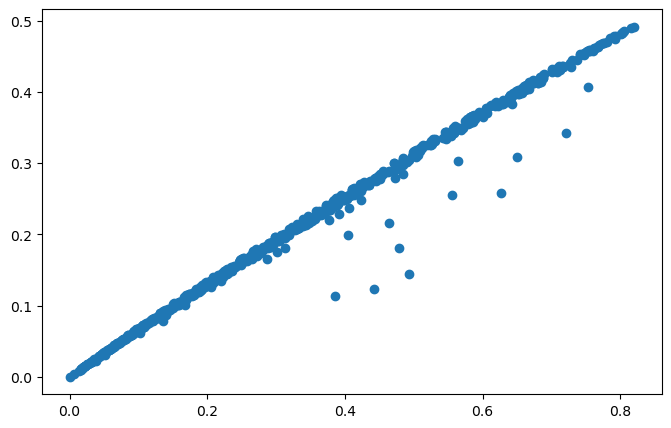

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(glc_transposed.iloc[:,1], glc_transposed.iloc[:,4])
plt.show()


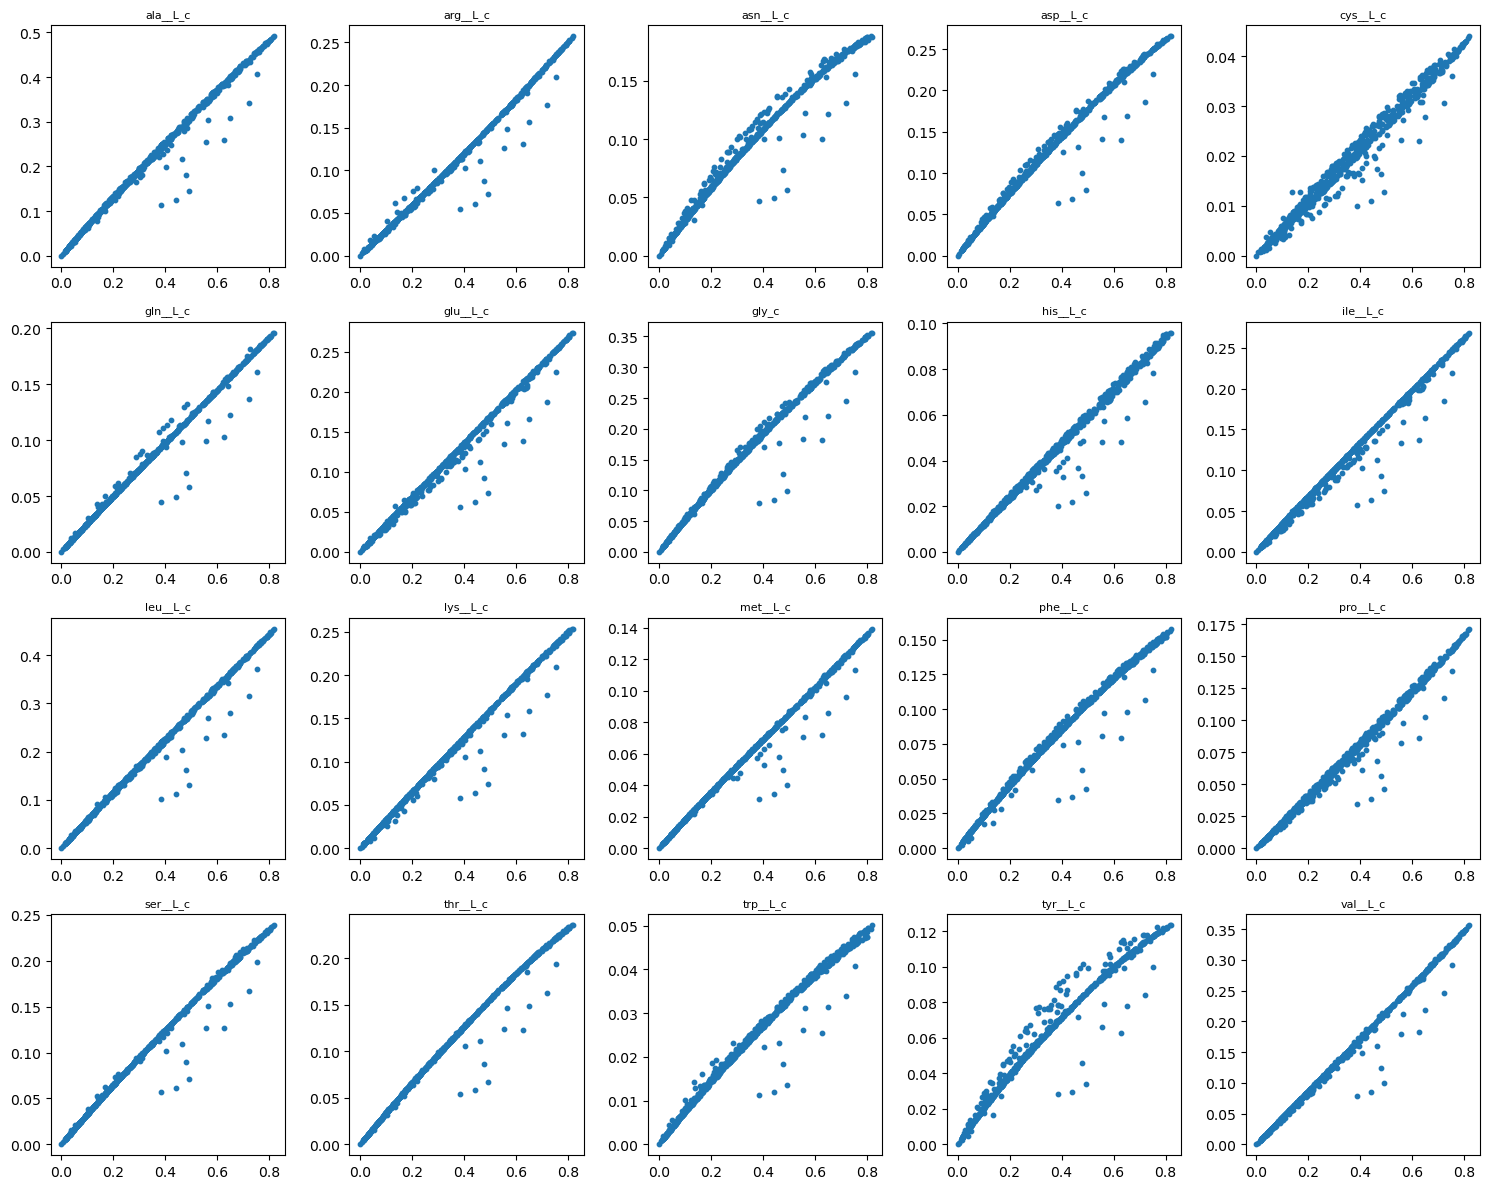

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x = glc_transposed.iloc[:, 1]  # reference column

aa_cols = glc_transposed.columns[4:]
n = len(aa_cols)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = axes.flatten()

for ax, col in zip(axes, aa_cols):
    ax.scatter(x, glc_transposed[col], s=10)
    ax.set_title(col, fontsize=8)

# remove unused axes
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**Sjekker for no3**

In [12]:
no3_samples = prep.get_samples(path='/triumvirate/home/celinaha/LHS_sampling/lhs_no3/results_glc/flux')
no3 = prep.merge_samples(no3_samples, '/triumvirate/home/celinaha/thesis_files/aa_template.csv', substrate='no3_glc')

In [13]:
meta_cols = ["reaction", "amino_acid"]
flux_cols = no3.columns[2:]

# keep first 3 rows separately
first_three = no3.iloc[:3][["reaction", *flux_cols]].copy()
first_three = first_three.rename(columns={"reaction": "feature"})

# charging rows only
charging = no3[no3["reaction"].str.startswith("charging", na=False)].copy()

# extract only amino acid from: generic_tRNA_codon_aminoacid_c
charging["feature"] = charging["amino_acid"].str.replace(
    r"^generic_tRNA_[^_]+_",
    "",
    regex=True
)

# aggregate so each amino acid appears once
aa_agg = (
    charging
    .groupby("feature", as_index=False)[flux_cols]
    .sum()
)

# combine first 3 reactions + amino acids
combined = pd.concat(
    [first_three[["feature", *flux_cols]], aa_agg],
    ignore_index=True
)

# transpose: FBA simulations as rows, features as columns
no3_transposed = (
    combined
    .set_index("feature")
    .T
    .reset_index()
    .rename(columns={"index": "sample"})
)

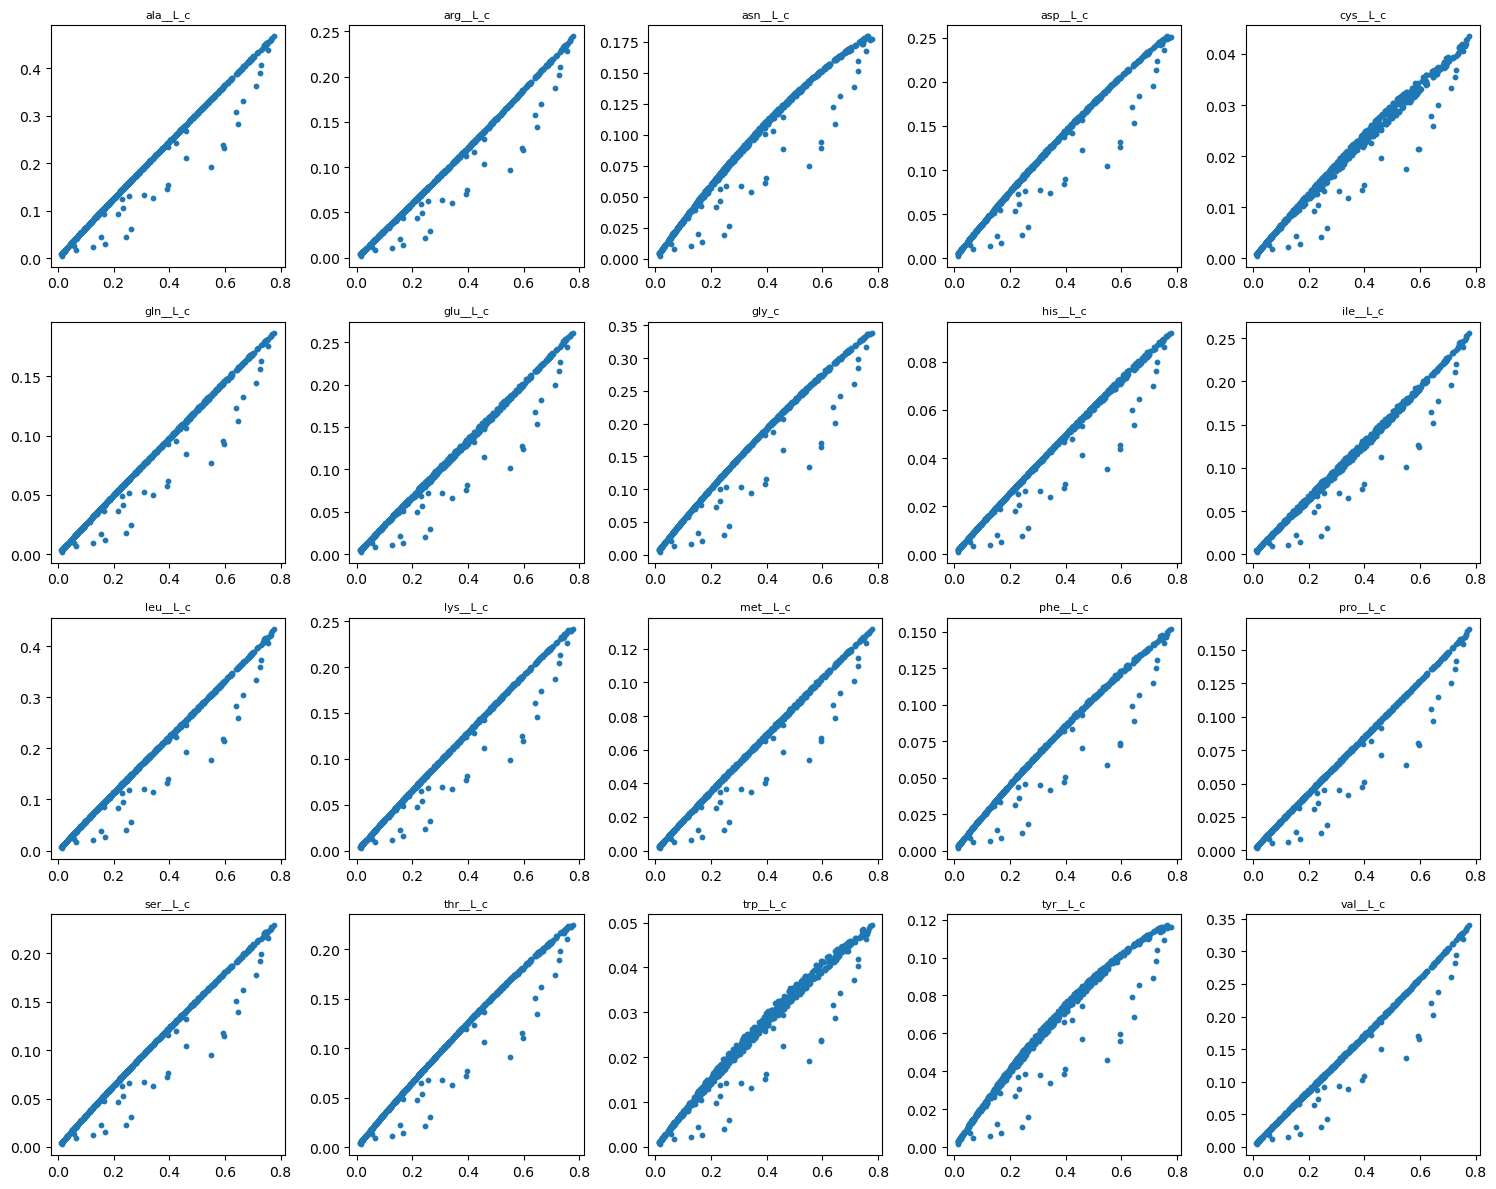

In [15]:
x = no3_transposed.iloc[:, 1]  # reference column

aa_cols = no3_transposed.columns[4:]
n = len(aa_cols)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = axes.flatten()

for ax, col in zip(axes, aa_cols):
    ax.scatter(x, no3_transposed[col], s=10)
    ax.set_title(col, fontsize=8)

# remove unused axes
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Lipid flux vs nutrient uptake flux

In [12]:
import matplotlib.pyplot as plt
import math

def plot_by_source_subplots(
    plot_df,
    y_col,
    source_col='source',
    source_to_xcol=None,
    sources_to_plot=None,
    dataset=None,
    outlier_col='outlier',
    ncols=4,
    figsize_per_col=(5, 4),
    non_outlier_color='green',
    outlier_color='red',
    non_outlier_alpha=0.2,
    outlier_alpha=0.6
):
    """
    Plot one subplot per source value, where the x-variable is chosen from a
    mapped dataframe column based on the first token of the source name.

    Parameters
    ----------
    plot_df : pd.DataFrame
        DataFrame containing source column, y column, and x columns.
    y_col : str
        Column name to plot on the y-axis.
    source_col : str, default='source'
        Column containing source names like 'glc', 'arg_glc', etc.
    source_to_xcol : dict
        Mapping from source token -> dataframe x column.
        Example:
            {
                'glc': 'EX_glc__D_e',
                'ac': 'EX_ac_e',
                'arg': 'EX_arg__L_e',
                ...
            }
    sources_to_plot : list, optional
        Ordered list of full source labels to include as subplots.
        If None, all unique values in source_col are used.
    dataset : pd.DataFrame, optional
        DataFrame containing outlier column aligned by index.
    outlier_col : str, default='outlier'
        Column in dataset used to identify outliers (1=True).
    ncols : int, default=4
        Number of subplot columns.
    figsize_per_col : tuple, default=(5, 4)
        Width, height per subplot grid unit.
    non_outlier_color : str, default='green'
    outlier_color : str, default='red'
    non_outlier_alpha : float, default=0.2
    outlier_alpha : float, default=0.6

    Returns
    -------
    fig, axes
    """
    if source_to_xcol is None:
        raise ValueError("source_to_xcol must be provided.")

    df = plot_df.copy()

    if sources_to_plot is not None:
        df = df[df[source_col].isin(sources_to_plot)].copy()
        sources_present = [s for s in sources_to_plot if s in df[source_col].unique()]
    else:
        sources_present = list(df[source_col].dropna().unique())

    if len(sources_present) == 0:
        raise ValueError("No matching sources found to plot.")

    # Use first token of source to determine x-column
    df['x_token'] = df[source_col].str.split('_').str[0]
    df['x_col'] = df['x_token'].map(source_to_xcol)

    # Drop rows where no x-column mapping exists
    df = df.dropna(subset=['x_col']).copy()

    # Extract x values row-wise
    df['x_val'] = [df.loc[idx, col_name] for idx, col_name in df['x_col'].items()]

    # Build outlier mask
    if dataset is not None and outlier_col in dataset.columns:
        outlier_mask = dataset.loc[df.index, outlier_col] == 1
    else:
        outlier_mask = None

    n = len(sources_present)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_col[0] * ncols, figsize_per_col[1] * nrows)
    )
    axes = axes.flatten() if n > 1 else [axes]

    for i, src in enumerate(sources_present):
        ax = axes[i]
        sub = df[df[source_col] == src]

        if sub.empty:
            fig.delaxes(ax)
            continue

        if outlier_mask is not None:
            sub_out = outlier_mask.loc[sub.index]

            ax.scatter(
                sub.loc[~sub_out, 'x_val'],
                sub.loc[~sub_out, y_col],
                alpha=non_outlier_alpha,
                color=non_outlier_color
            )

            ax.scatter(
                sub.loc[sub_out, 'x_val'],
                sub.loc[sub_out, y_col],
                alpha=outlier_alpha,
                color=outlier_color
            )
        else:
            ax.scatter(
                sub['x_val'],
                sub[y_col],
                alpha=non_outlier_alpha,
                color=non_outlier_color
            )

        ax.set_title(src)
        ax.set_xlabel(sub['x_col'].iloc[0])
        ax.set_ylabel(y_col)

    # Remove unused axes
    for j in range(len(sources_present), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    return fig, axes

In [13]:
bm = data.iloc[:, :12]
# bm = noise_data.iloc[:, :11]
bm_plot = bm.copy()
bm_plot.columns = bm_plot.columns.str.split('_').str[0]
bm_plot = bm_plot.rename(columns={'dummy': 'dummy protein'})

In [14]:
bm_plot['source'] = data['source']
bm_plot['outlier'] = data['outlier']

ex_cols = ['EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

In [15]:
lipid_plot = bm_plot[['lipid', 'source']].copy()
lipid_plot[ex_cols] = -data[ex_cols]
lipid_plot['outlier'] = data['outlier']

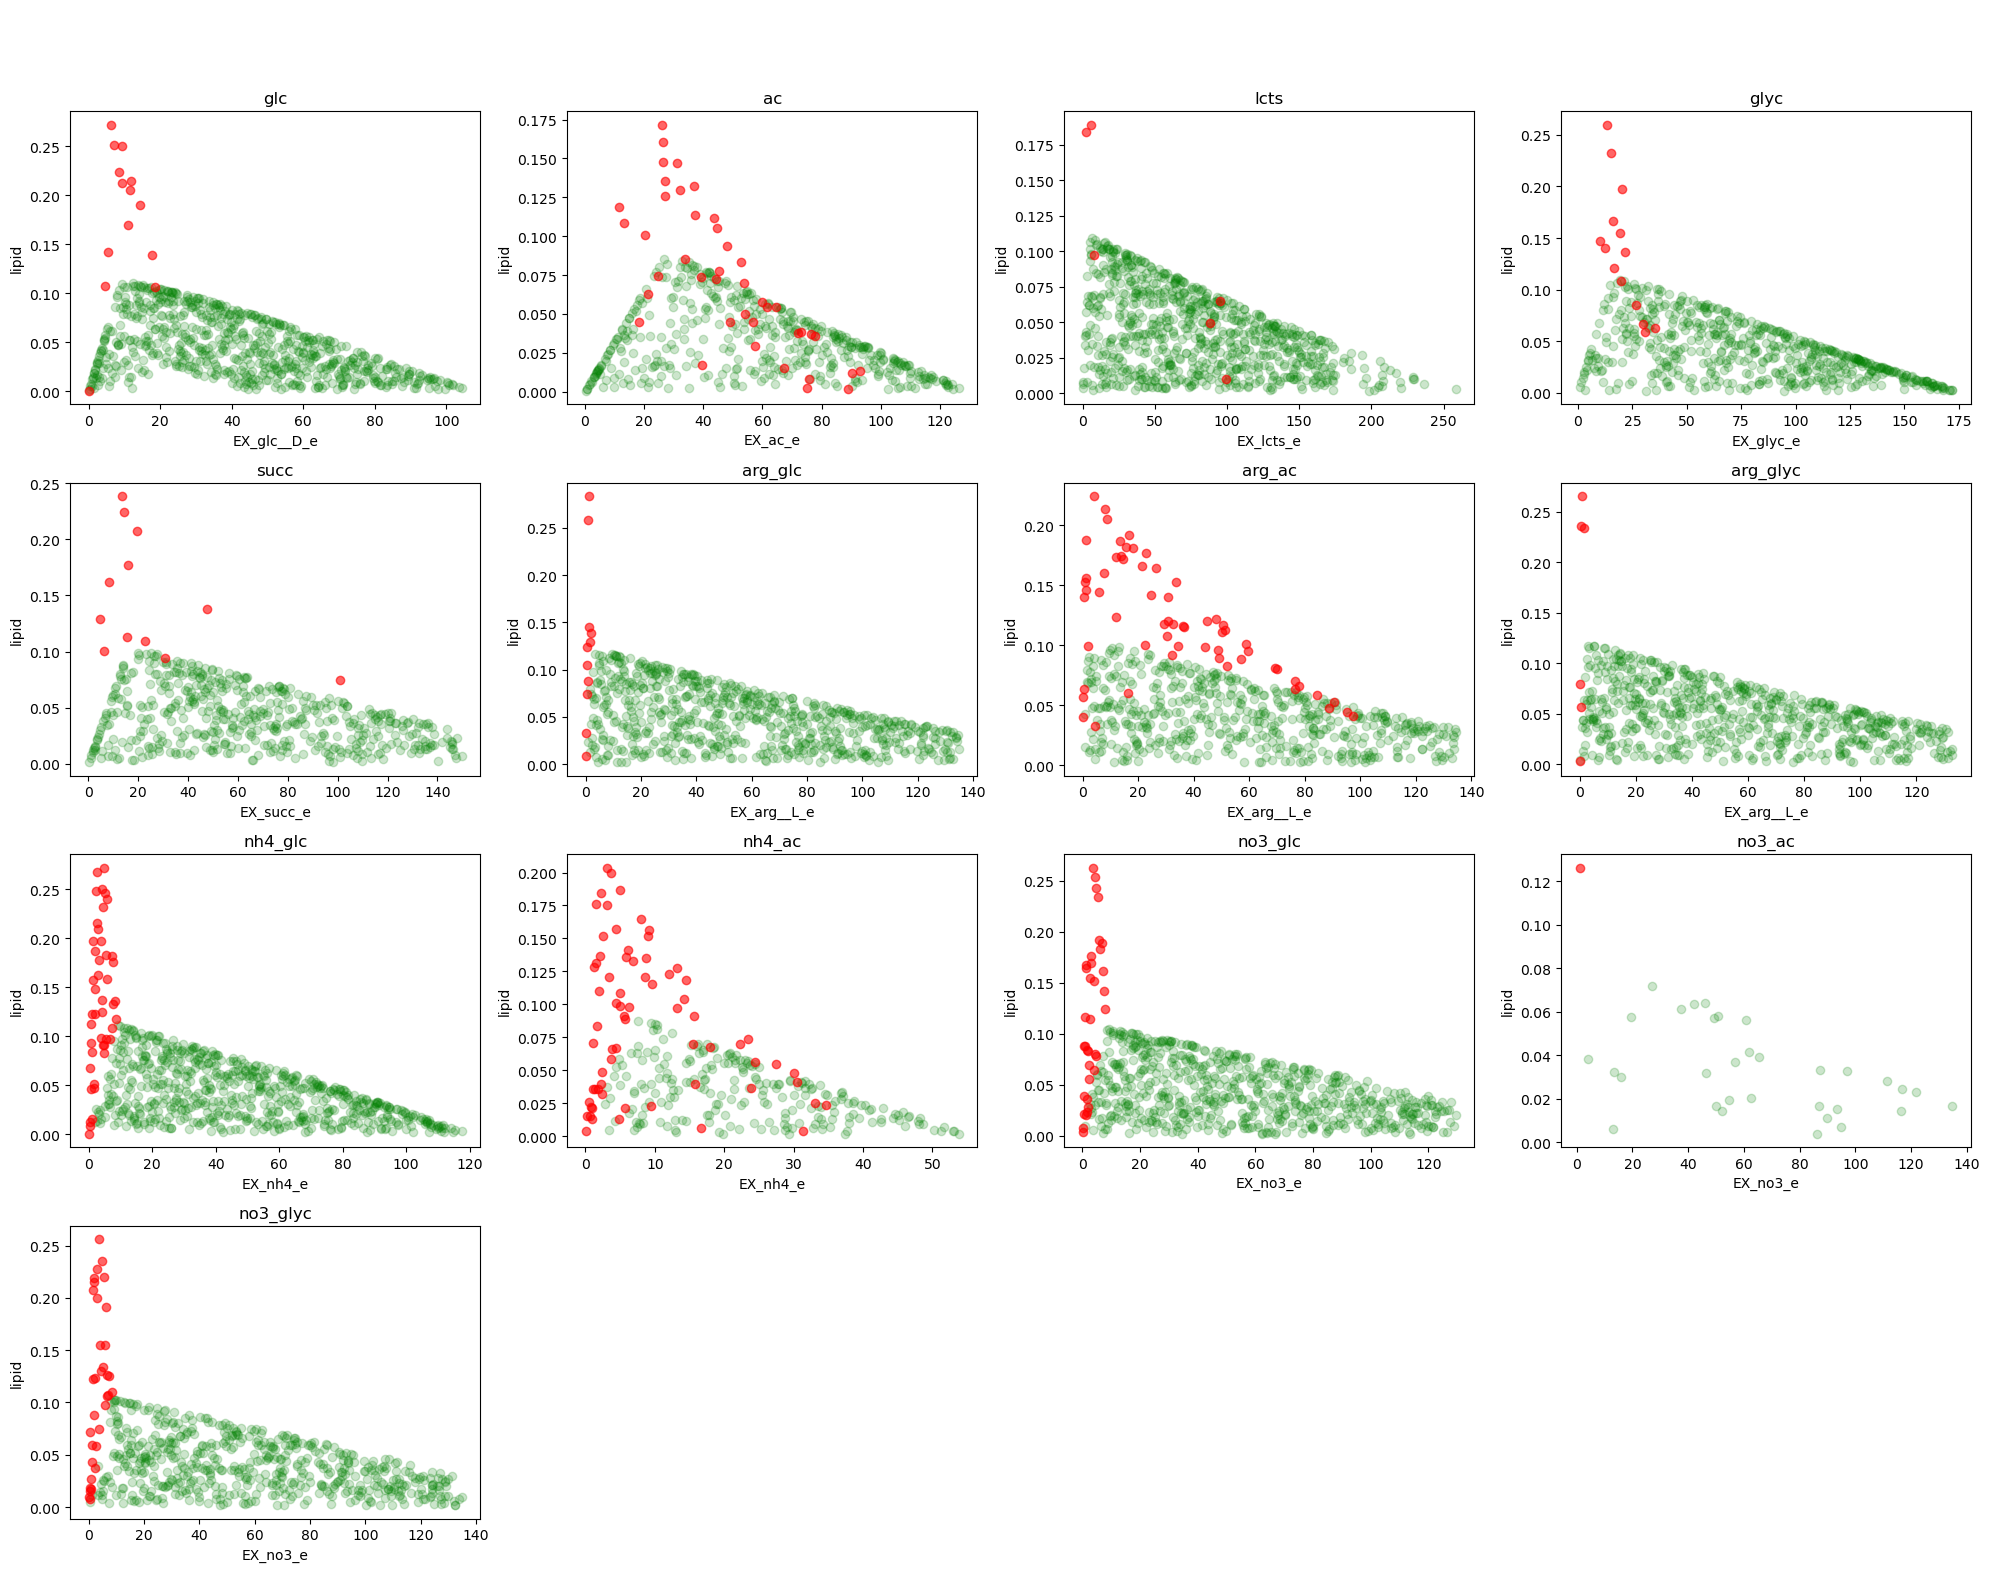

In [18]:
sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_ac', 'no3_glyc'
]

source_to_ex = {
    'glc': 'EX_glc__D_e',
    'ac': 'EX_ac_e',
    'lcts': 'EX_lcts_e',
    'glyc': 'EX_glyc_e',
    'succ': 'EX_succ_e',
    'arg': 'EX_arg__L_e',
    'nh4': 'EX_nh4_e',
    'no3': 'EX_no3_e'
}

fig, axes = plot_by_source_subplots(
    plot_df=lipid_plot,
    y_col='lipid',
    source_col='source',
    source_to_xcol=source_to_ex,
    sources_to_plot=sources_to_plot,
    dataset=data,
    outlier_col='outlier',
    ncols=4
)

plt.suptitle('Prosthetic Group Biomass vs Source Uptake', fontsize=15, color='white')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

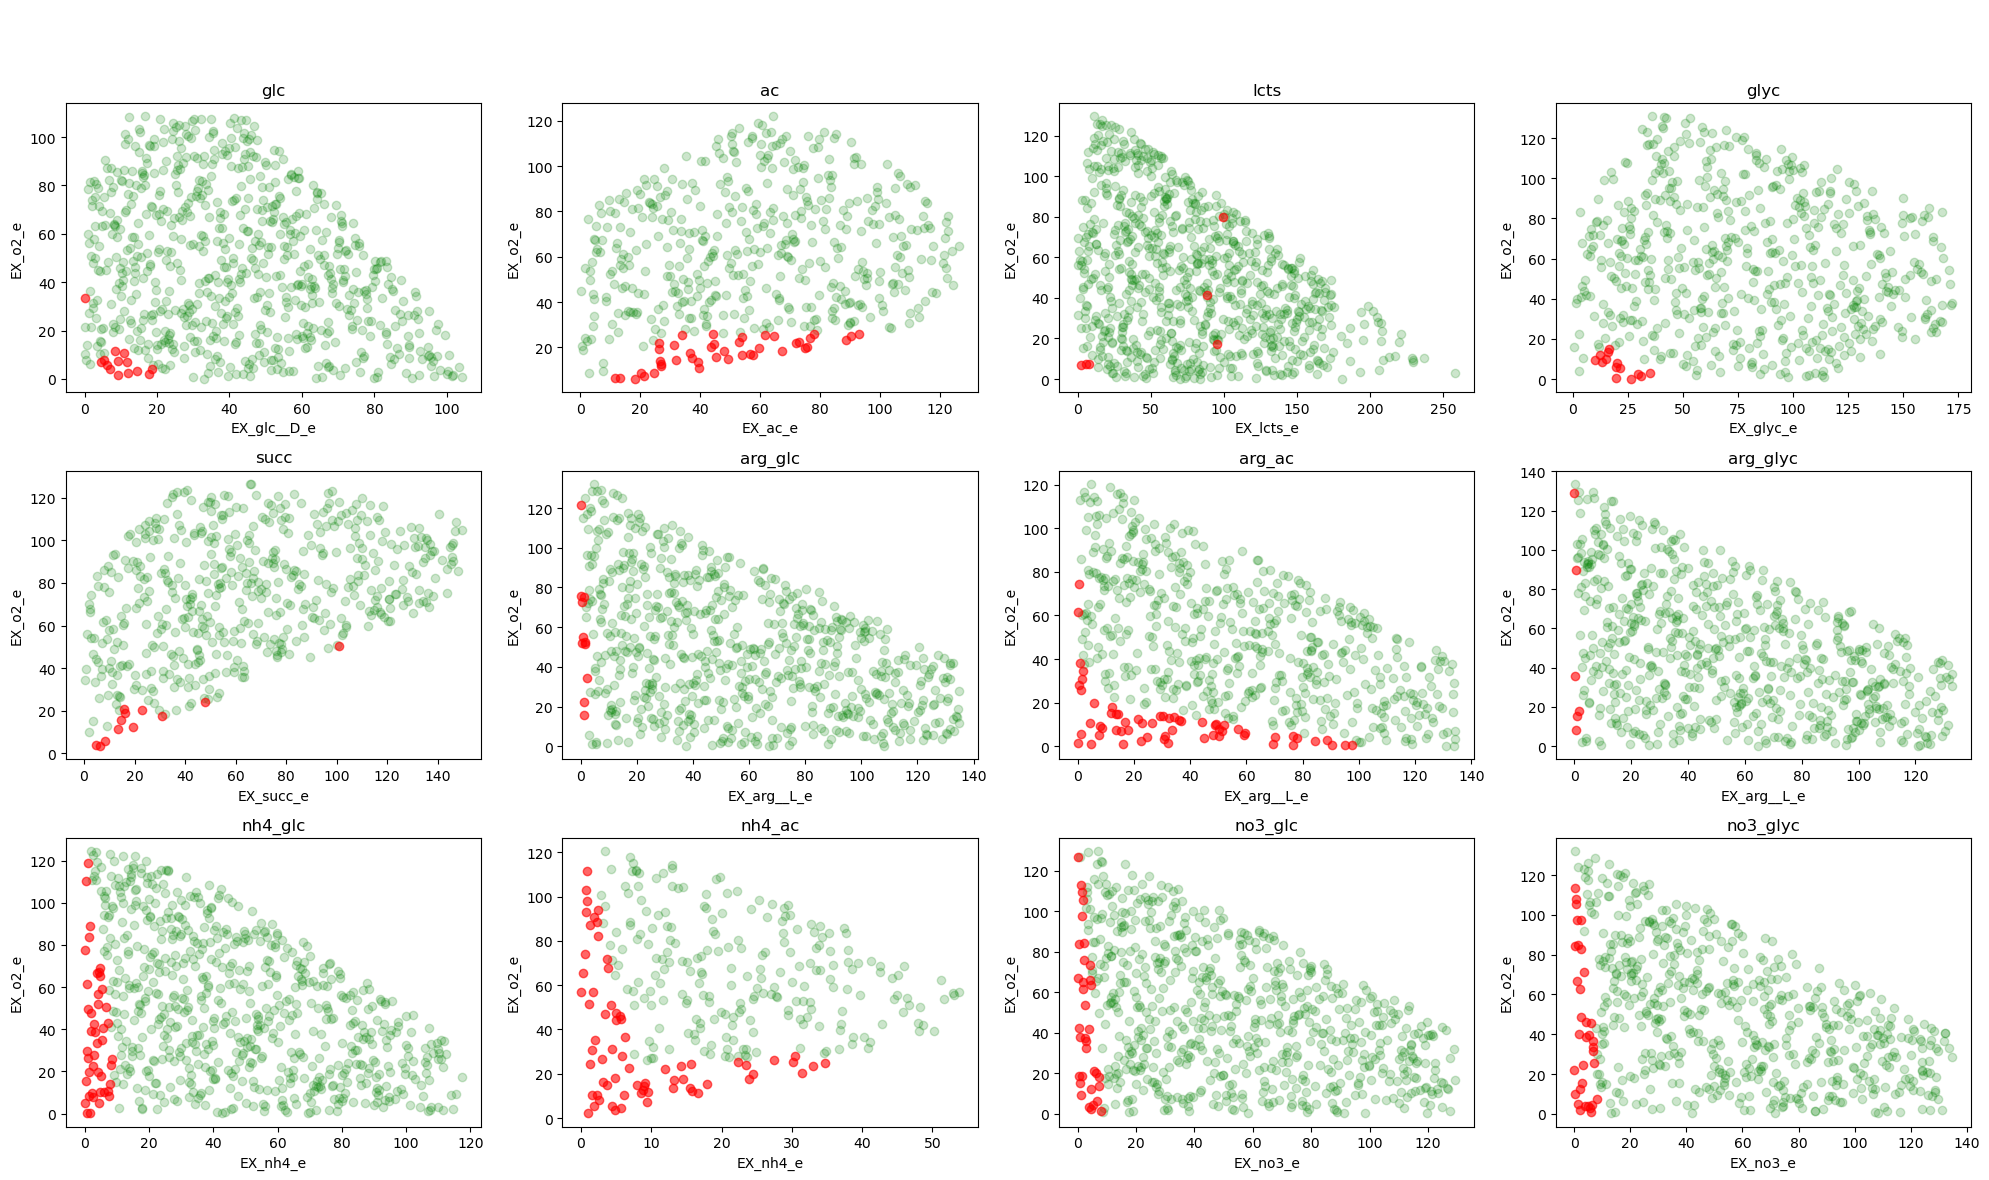

In [39]:
sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_glyc'
]

source_to_ex = {
    'glc': 'EX_glc__D_e',
    'ac': 'EX_ac_e',
    'lcts': 'EX_lcts_e',
    'glyc': 'EX_glyc_e',
    'succ': 'EX_succ_e',
    'arg': 'EX_arg__L_e',
    'nh4': 'EX_nh4_e',
    'no3': 'EX_no3_e'
}

fig, axes = plot_by_source_subplots(
    plot_df=lipid_plot,
    y_col='EX_o2_e',
    source_col='source',
    source_to_xcol=source_to_ex,
    sources_to_plot=sources_to_plot,
    dataset=data,
    outlier_col='outlier',
    ncols=4
)

plt.suptitle('Prosthetic Group Biomass vs Source Uptake', fontsize=15, color='white')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [40]:
glc_outliers

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2
152,glc_sample_152,0.072573,3.862148e-04,0.002345,0.016749,3.164671e-05,0.020318,0.212064,0.009853,7.650367e-05,...,0.0,0.0,0.0,0.0,0.0,glc,1,-9.936895e-04,-0.000434,0.550
269,glc_sample_269,0.079072,4.515476e-04,0.002742,0.019580,3.967346e-05,0.021780,0.250824,0.011302,9.429584e-05,...,0.0,0.0,0.0,0.0,0.0,glc,1,-9.131616e-04,-0.000572,0.567
277,glc_sample_277,0.224226,1.705666e-03,0.010356,0.073979,1.246809e-04,0.023233,0.223305,0.018431,3.632803e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-6.929262e-04,-0.000901,0.310
285,glc_sample_285,0.165884,1.074762e-03,0.006527,0.046624,7.523574e-05,0.023060,0.189800,0.014201,2.105385e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-7.966844e-04,-0.000331,0.342
288,glc_sample_288,0.139277,7.569364e-04,0.004595,0.032826,3.757830e-05,0.020895,0.107061,0.010355,1.528638e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-1.015586e-02,-0.057792,0.264
334,glc_sample_334,0.000130,3.462005e-07,0.000002,0.000015,3.917916e-11,0.000031,0.000242,0.000013,5.455398e-08,...,0.0,0.0,0.0,0.0,0.0,glc,1,7.366932e-08,-0.000692,0.466
373,glc_sample_373,0.167419,1.166758e-03,0.007085,0.050606,9.089648e-05,0.023200,0.250350,0.016028,2.408359e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-7.500258e-04,-0.000401,0.399
415,glc_sample_415,0.249555,1.764351e-03,0.010716,0.076549,1.097723e-04,0.023205,0.106249,0.016420,3.418153e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-7.227430e-04,-0.000272,0.165
436,glc_sample_436,0.116249,6.926128e-04,0.004207,0.030042,5.149150e-05,0.022407,0.214856,0.012245,1.366245e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-8.627490e-04,-0.000384,0.449
563,glc_sample_563,0.265969,2.082383e-03,0.012644,0.090331,1.468237e-04,0.023280,0.169756,0.019262,4.244251e-04,...,0.0,0.0,0.0,0.0,0.0,glc,1,-6.402248e-04,-0.000288,0.225


### marking samples based on different Lpp modification

In [24]:
data["lipid_dev"] = (
    bm_data["b1677_lipid_modification_pg120_p_pe160"]
    .ne(0)
    .astype(int)
    .to_numpy()
)

In [35]:
lipid_plot["EX_o2_e"] = data["EX_o2_e"].tolist()
lipid_plot["EX_o2_e"] = -lipid_plot["EX_o2_e"]

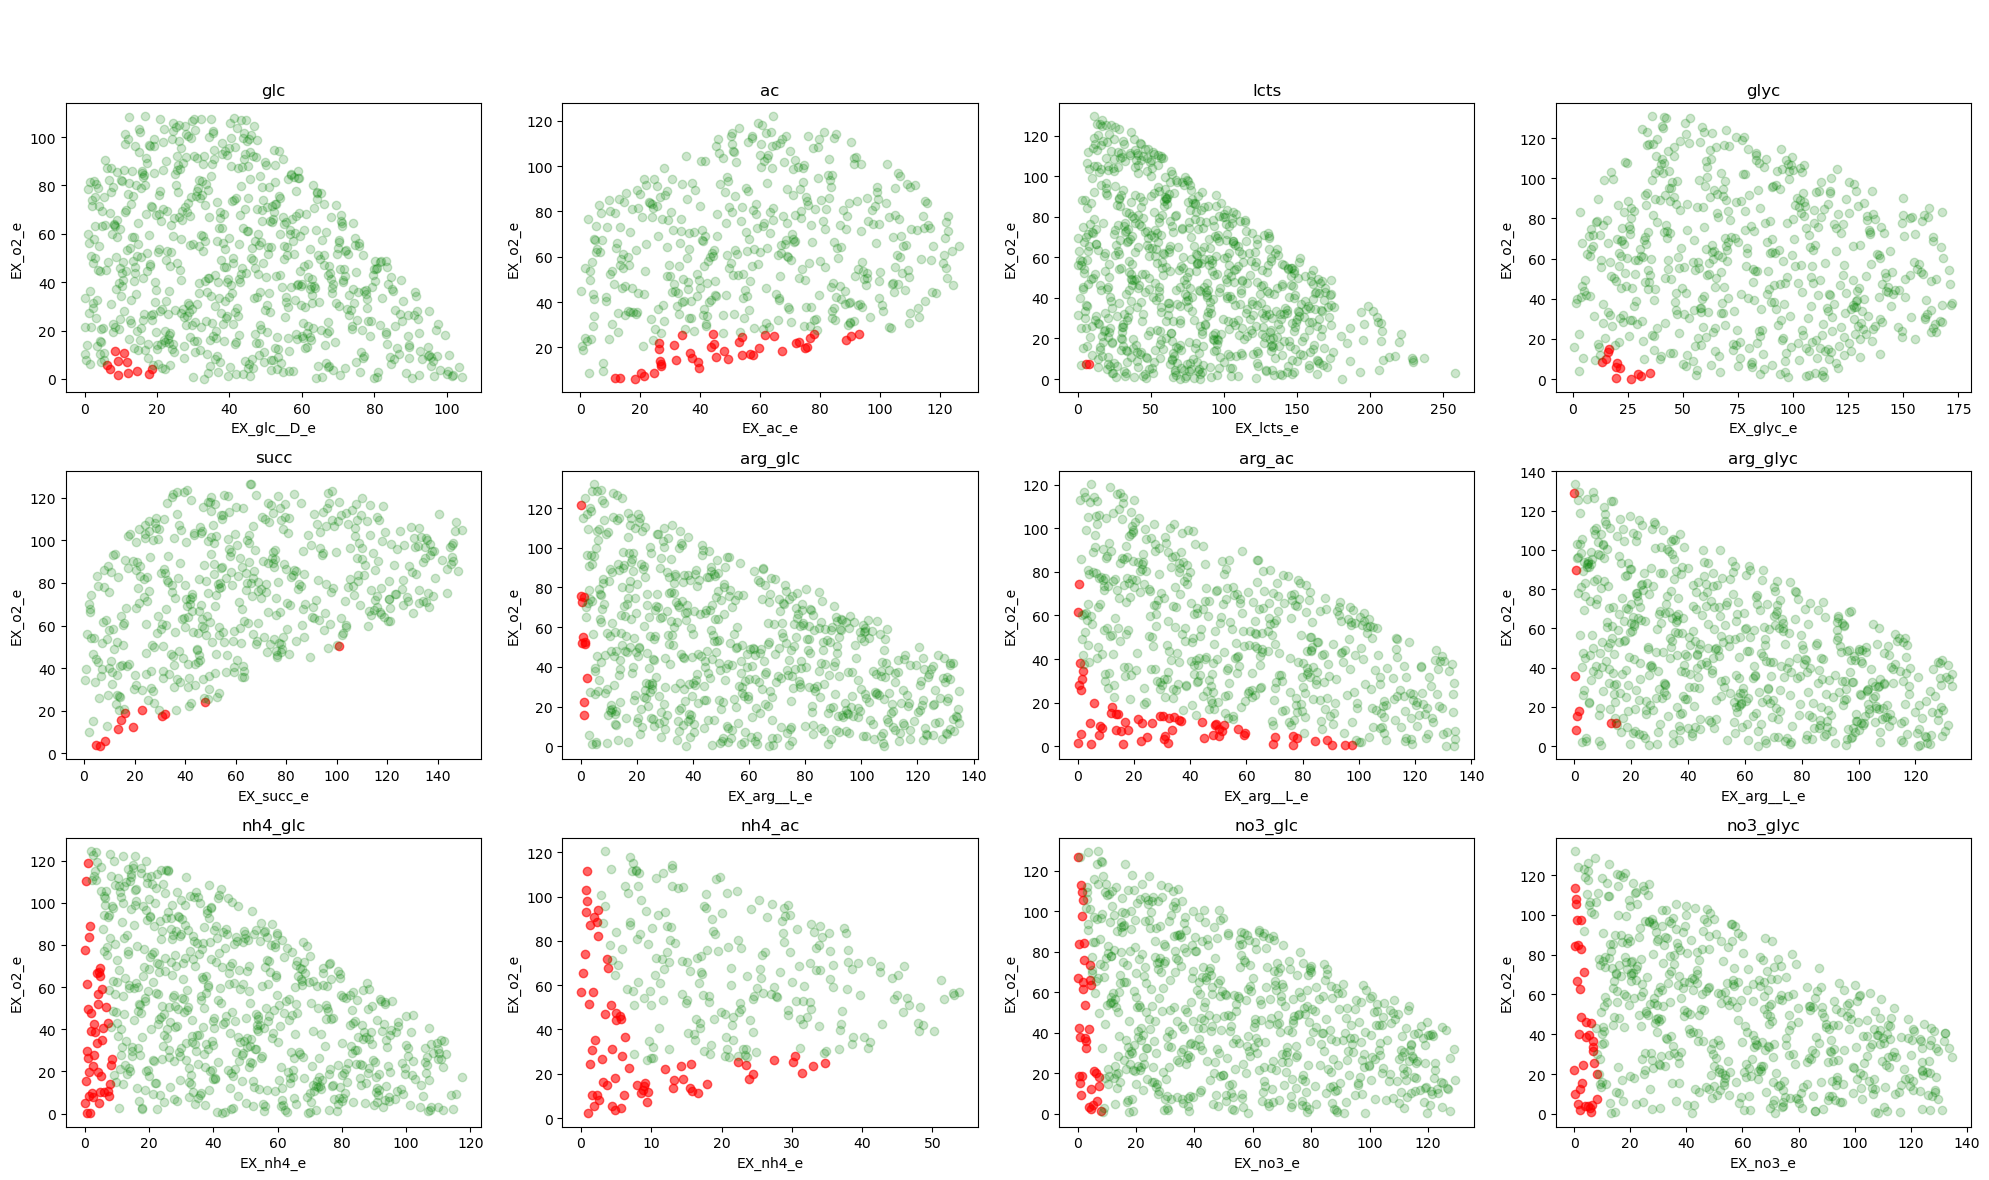

In [38]:
sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_glyc'
]

source_to_ex = {
    'glc': 'EX_glc__D_e',
    'ac': 'EX_ac_e',
    'lcts': 'EX_lcts_e',
    'glyc': 'EX_glyc_e',
    'succ': 'EX_succ_e',
    'arg': 'EX_arg__L_e',
    'nh4': 'EX_nh4_e',
    'no3': 'EX_no3_e'
}

fig, axes = plot_by_source_subplots(
    plot_df=lipid_plot,
    y_col='EX_o2_e',
    source_col='source',
    source_to_xcol=source_to_ex,
    sources_to_plot=sources_to_plot,
    dataset=data,
    outlier_col='lipid_dev',
    ncols=4,
    non_outlier_color="red",
    outlier_color="green",
    non_outlier_alpha=0.6,
    outlier_alpha=0.2
)

plt.suptitle('Prosthetic Group Biomass vs Source Uptake', fontsize=15, color='white')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

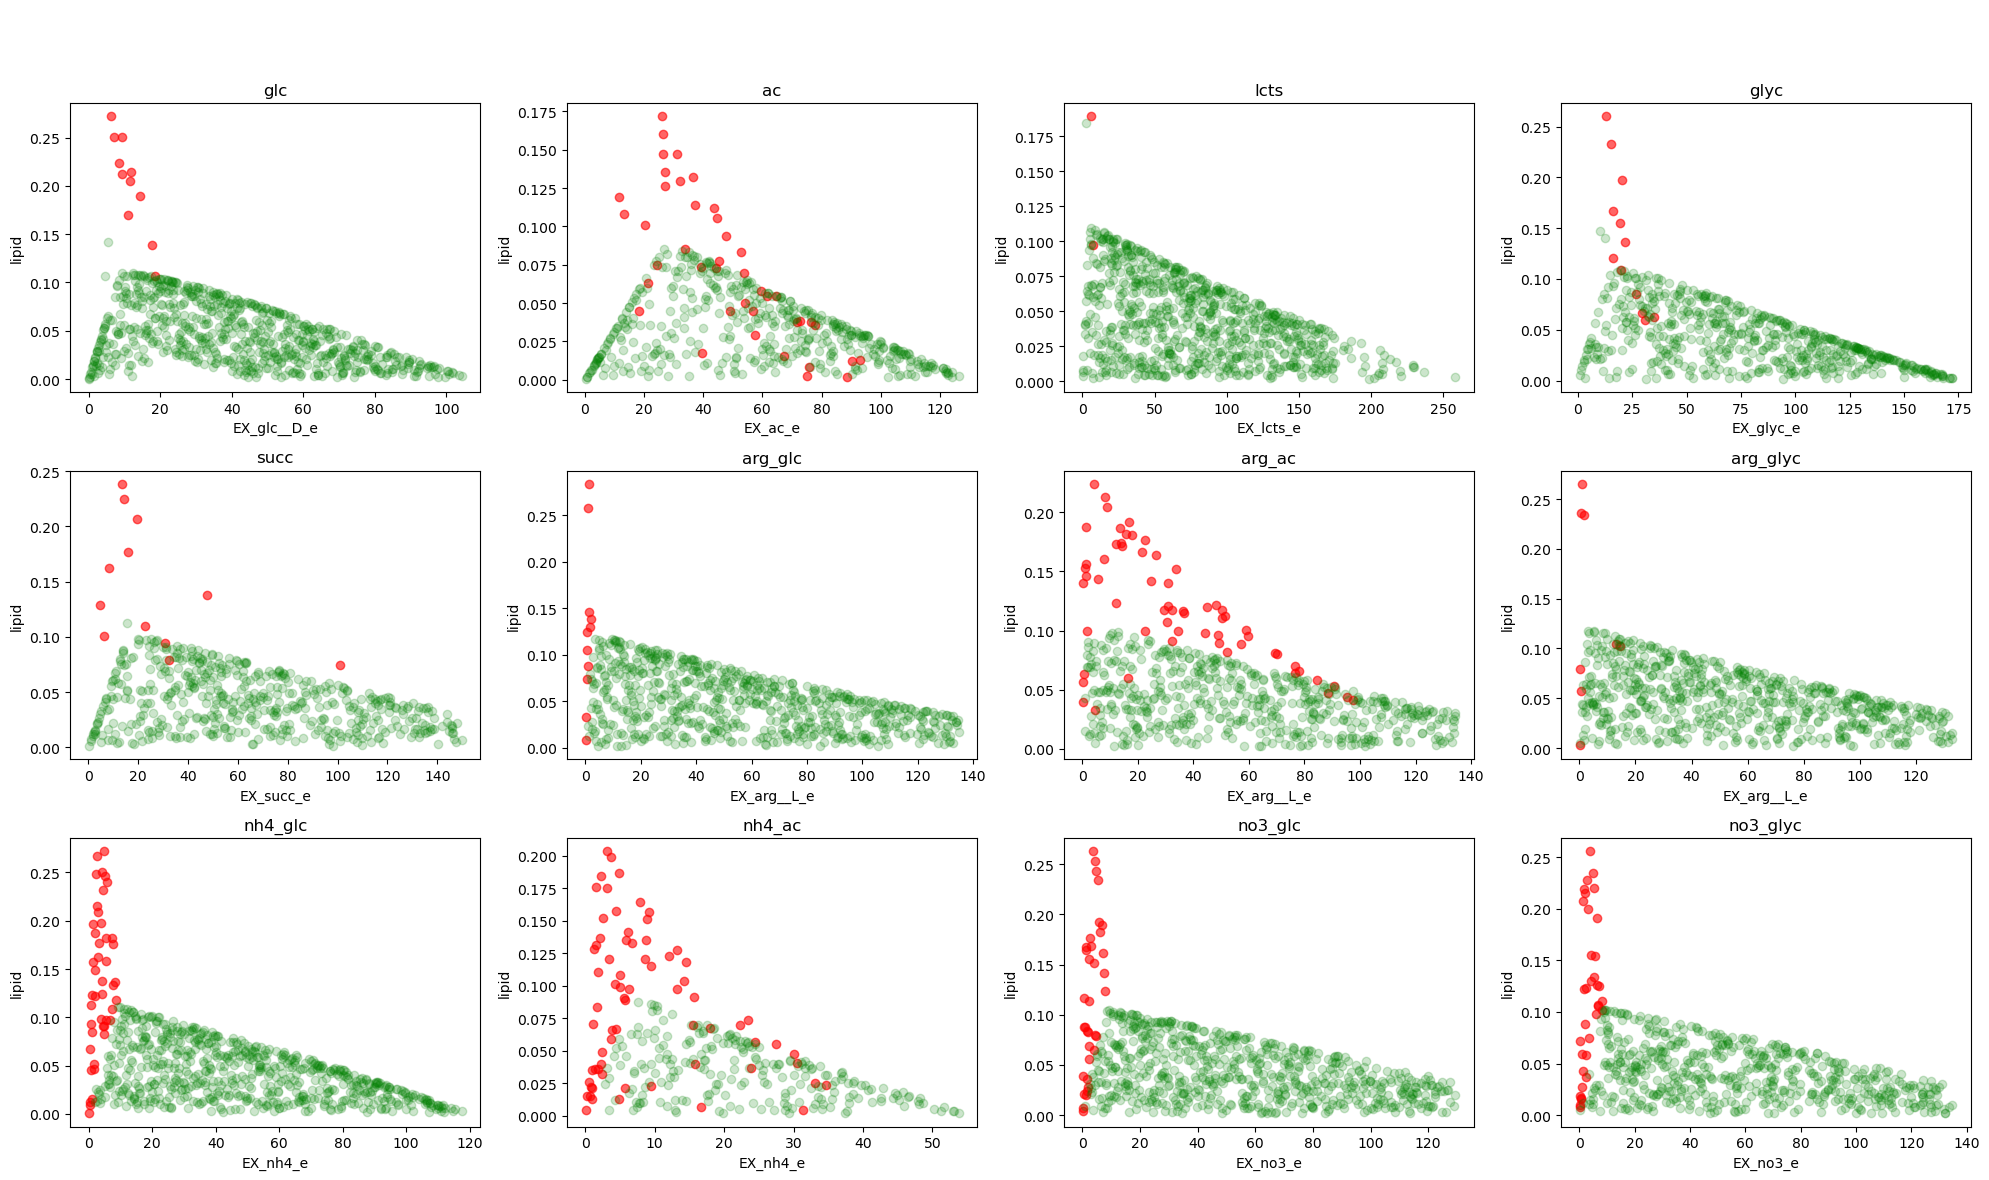

In [45]:
sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_glyc'
]

source_to_ex = {
    'glc': 'EX_glc__D_e',
    'ac': 'EX_ac_e',
    'lcts': 'EX_lcts_e',
    'glyc': 'EX_glyc_e',
    'succ': 'EX_succ_e',
    'arg': 'EX_arg__L_e',
    'nh4': 'EX_nh4_e',
    'no3': 'EX_no3_e'
}

fig, axes = plot_by_source_subplots(
    plot_df=lipid_plot,
    y_col='lipid',
    source_col='source',
    source_to_xcol=source_to_ex,
    sources_to_plot=sources_to_plot,
    dataset=data,
    outlier_col='lipid_dev',
    ncols=4,
    non_outlier_color="red",
    outlier_color="green",
    non_outlier_alpha=0.6,
    outlier_alpha=0.2
)

plt.suptitle('Prosthetic Group Biomass vs Source Uptake', fontsize=15, color='white')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# outliers vs lipid devs:

In [65]:
# glc_outliers

# ac_outliers = data[data["source"]=="ac"]
# ac_outliers = ac_outliers[ac_outliers["outlier"]==1]
# ac_outliers

### Finding "lost" lipid devs

**Glucose**

In [43]:
glc_lip_dev = data[data["lipid_dev"]==0]
glc_lip_dev = glc_lip_dev[glc_lip_dev["source"]=="glc"]

glc_lip_dev

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2,lipid_dev
152,glc_sample_152,0.072573,0.000386,0.002345,0.016749,0.000032,0.020318,0.212064,0.009853,0.000077,...,0.0,0.0,0.0,0.0,glc,1,-0.000994,-0.000434,0.550,0
269,glc_sample_269,0.079072,0.000452,0.002742,0.019580,0.000040,0.021780,0.250824,0.011302,0.000094,...,0.0,0.0,0.0,0.0,glc,1,-0.000913,-0.000572,0.567,0
277,glc_sample_277,0.224226,0.001706,0.010356,0.073979,0.000125,0.023233,0.223305,0.018431,0.000363,...,0.0,0.0,0.0,0.0,glc,1,-0.000693,-0.000901,0.310,0
285,glc_sample_285,0.165884,0.001075,0.006527,0.046624,0.000075,0.023060,0.189800,0.014201,0.000211,...,0.0,0.0,0.0,0.0,glc,1,-0.000797,-0.000331,0.342,0
373,glc_sample_373,0.167419,0.001167,0.007085,0.050606,0.000091,0.023200,0.250350,0.016028,0.000241,...,0.0,0.0,0.0,0.0,glc,1,-0.000750,-0.000401,0.399,0
415,glc_sample_415,0.249555,0.001764,0.010716,0.076549,0.000110,0.023205,0.106249,0.016420,0.000342,...,0.0,0.0,0.0,0.0,glc,1,-0.000723,-0.000272,0.165,0
436,glc_sample_436,0.116249,0.000693,0.004207,0.030042,0.000051,0.022407,0.214856,0.012245,0.000137,...,0.0,0.0,0.0,0.0,glc,1,-0.000863,-0.000384,0.449,0
563,glc_sample_563,0.265969,0.002082,0.012644,0.090331,0.000147,0.023280,0.169756,0.019262,0.000424,...,0.0,0.0,0.0,0.0,glc,1,-0.000640,-0.000288,0.225,0
572,glc_sample_572,0.201632,0.001437,0.008726,0.062331,0.000106,0.023206,0.205502,0.016630,0.000290,...,0.0,0.0,0.0,0.0,glc,1,-0.000730,-0.000379,0.316,0
642,glc_sample_642,0.092205,0.000558,0.003389,0.024203,0.000048,0.022580,0.271872,0.012590,0.000121,...,0.0,0.0,0.0,0.0,glc,1,-0.000897,-0.001206,0.552,0


In [50]:
bm_data_lip_dev = bm_data.loc[
    bm_data.index.isin(glc_lip_dev["sample"])
].copy()

In [59]:
bm_data_lip_dev["b1677_lipid_modification_pg161_p_pe160"]

glc_sample_152    0.000000
glc_sample_269    0.000000
glc_sample_277    0.002593
glc_sample_285    0.000000
glc_sample_373    0.000000
glc_sample_415    0.000000
glc_sample_436    0.000000
glc_sample_563    0.000000
glc_sample_572    0.000000
glc_sample_642    0.001771
glc_sample_679    0.000000
Name: b1677_lipid_modification_pg161_p_pe160, dtype: float64

In [76]:
bm_data_lip_dev["EX_o2_e"]

glc_sample_152    -1.596374
glc_sample_269    -4.048472
glc_sample_277   -11.690847
glc_sample_285    -3.087152
glc_sample_373    -7.442252
glc_sample_415    -3.915147
glc_sample_436    -2.321342
glc_sample_563   -10.663566
glc_sample_572    -6.962712
glc_sample_642    -5.925201
glc_sample_679    -2.071203
Name: EX_o2_e, dtype: float64

**Glycerol:**

In [66]:
glyc_outliers = data[data["source"]=="glyc"]
glyc_outliers = glyc_outliers[glyc_outliers["outlier"]==1]
glyc_outliers

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2,lipid_dev
1978,glyc_sample_7,0.141113,0.000940,0.005706,0.040754,0.000073,0.023144,0.260017,0.014868,0.000197,...,-13.166518,0.0,0.0,0.0,glyc,1,-0.000924,-0.000182,0.447,0
2026,glyc_sample_55,0.229606,0.001613,0.009789,0.069946,0.000099,0.023203,0.140119,0.016286,0.000349,...,-12.300473,0.0,0.0,0.0,glyc,1,-0.010966,-0.032135,0.220,1
2078,glyc_sample_107,0.167810,0.001045,0.006347,0.045333,0.000066,0.022853,0.155278,0.013306,0.000275,...,-19.511338,0.0,0.0,0.0,glyc,1,-0.000936,-0.000093,0.298,0
2091,glyc_sample_120,0.274333,0.002177,0.013216,0.094425,0.000145,0.023316,0.166831,0.019666,0.000449,...,-16.095431,0.0,0.0,0.0,glyc,1,-0.000716,-0.000540,0.217,0
2166,glyc_sample_195,0.191000,0.001117,0.006783,0.048452,0.000055,0.022179,0.062404,0.011858,0.000280,...,-35.226839,0.0,0.0,0.0,glyc,1,-0.000825,-0.000057,0.135,0
2300,glyc_sample_329,0.155502,0.000824,0.005003,0.035739,0.000043,0.020285,0.059254,0.009827,0.000250,...,-30.963759,0.0,0.0,0.0,glyc,1,-0.001111,-0.000141,0.154,0
2319,glyc_sample_348,0.099067,0.000465,0.002823,0.020160,0.000024,0.016737,0.084738,0.007548,0.000152,...,-26.623171,0.0,0.0,0.0,glyc,1,-0.001171,-0.000179,0.287,0
2330,glyc_sample_359,0.063148,0.000276,0.001678,0.011980,0.000015,0.014396,0.108501,0.006354,0.000093,...,-19.740102,0.0,0.0,0.0,glyc,1,-0.001203,-0.000199,0.437,0
2342,glyc_sample_371,0.181207,0.001225,0.007441,0.053157,0.000083,0.023172,0.197346,0.015259,0.000248,...,-20.162581,0.0,0.0,0.0,glyc,1,-0.000874,-0.000062,0.331,0
2361,glyc_sample_390,0.190402,0.001365,0.008288,0.059202,0.000099,0.023207,0.232453,0.016785,0.000282,...,-15.260752,0.0,0.0,0.0,glyc,1,-0.000848,-0.000144,0.354,0


In [67]:
glyc_lip_dev = data[data["lipid_dev"]==0]
glyc_lip_dev = glyc_lip_dev[glyc_lip_dev["source"]=="glyc"]

glyc_lip_dev

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2,lipid_dev
1978,glyc_sample_7,0.141113,0.000940,0.005706,0.040754,0.000073,0.023144,0.260017,0.014868,0.000197,...,-13.166518,0.0,0.0,0.0,glyc,1,-0.000924,-0.000182,0.447,0
2078,glyc_sample_107,0.167810,0.001045,0.006347,0.045333,0.000066,0.022853,0.155278,0.013306,0.000275,...,-19.511338,0.0,0.0,0.0,glyc,1,-0.000936,-0.000093,0.298,0
2091,glyc_sample_120,0.274333,0.002177,0.013216,0.094425,0.000145,0.023316,0.166831,0.019666,0.000449,...,-16.095431,0.0,0.0,0.0,glyc,1,-0.000716,-0.000540,0.217,0
2166,glyc_sample_195,0.191000,0.001117,0.006783,0.048452,0.000055,0.022179,0.062404,0.011858,0.000280,...,-35.226839,0.0,0.0,0.0,glyc,1,-0.000825,-0.000057,0.135,0
2300,glyc_sample_329,0.155502,0.000824,0.005003,0.035739,0.000043,0.020285,0.059254,0.009827,0.000250,...,-30.963759,0.0,0.0,0.0,glyc,1,-0.001111,-0.000141,0.154,0
2319,glyc_sample_348,0.099067,0.000465,0.002823,0.020160,0.000024,0.016737,0.084738,0.007548,0.000152,...,-26.623171,0.0,0.0,0.0,glyc,1,-0.001171,-0.000179,0.287,0
2330,glyc_sample_359,0.063148,0.000276,0.001678,0.011980,0.000015,0.014396,0.108501,0.006354,0.000093,...,-19.740102,0.0,0.0,0.0,glyc,1,-0.001203,-0.000199,0.437,0
2342,glyc_sample_371,0.181207,0.001225,0.007441,0.053157,0.000083,0.023172,0.197346,0.015259,0.000248,...,-20.162581,0.0,0.0,0.0,glyc,1,-0.000874,-0.000062,0.331,0
2361,glyc_sample_390,0.190402,0.001365,0.008288,0.059202,0.000099,0.023207,0.232453,0.016785,0.000282,...,-15.260752,0.0,0.0,0.0,glyc,1,-0.000848,-0.000144,0.354,0
2420,glyc_sample_449,0.170431,0.000950,0.005770,0.041218,0.000052,0.021406,0.066923,0.010866,0.000279,...,-29.701751,0.0,0.0,0.0,glyc,1,-0.001084,-0.000124,0.157,0


In [68]:
bm_data_lip_dev2 = bm_data.loc[
    bm_data.index.isin(glyc_lip_dev["sample"])
].copy()

In [73]:
bm_data_lip_dev2["b1677_lipid_modification_pg160_p_pe160"]

glyc_sample_7      0.000000
glyc_sample_107    0.000000
glyc_sample_120    0.000000
glyc_sample_195    0.001668
glyc_sample_329    0.000000
glyc_sample_348    0.000000
glyc_sample_359    0.000000
glyc_sample_371    0.000000
glyc_sample_390    0.000000
glyc_sample_449    0.000000
glyc_sample_488    0.000000
glyc_sample_541    0.000000
Name: b1677_lipid_modification_pg160_p_pe160, dtype: float64

In [78]:
bm_data_lip_dev2[ex_cols]

reaction,EX_glc__D_e,EX_ac_e,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_nh4_e,EX_no3_e
glyc_sample_7,0.0,1.800489,0.0,-13.166518,0.0,0.0,-4.274817,0.0
glyc_sample_107,0.0,8.968839,0.0,-19.511338,0.0,0.0,-4.702770,0.0
glyc_sample_120,0.0,2.644561,0.0,-16.095431,0.0,0.0,-7.702374,0.0
glyc_sample_195,0.0,7.414780,0.0,-35.226839,0.0,0.0,-5.087956,0.0
glyc_sample_329,0.0,11.322689,0.0,-30.963759,0.0,0.0,-4.060609,0.0
glyc_sample_348,0.0,9.505985,0.0,-26.623171,0.0,0.0,-2.682821,0.0
glyc_sample_359,0.0,7.268779,0.0,-19.740102,0.0,0.0,-1.838118,0.0
glyc_sample_371,0.0,3.826764,0.0,-20.162581,0.0,0.0,-5.197702,0.0
glyc_sample_390,0.0,3.088670,0.0,-15.260752,0.0,0.0,-5.533012,0.0
glyc_sample_449,0.0,11.235451,0.0,-29.701751,0.0,0.0,-4.468597,0.0


**Acetate**

In [80]:
ac_lip_dev = data[data["lipid_dev"]==0]
ac_lip_dev = ac_lip_dev[ac_lip_dev["source"]=="ac"]

In [81]:
bm_data_lip_dev3 = bm_data.loc[
    bm_data.index.isin(ac_lip_dev["sample"])
].copy()

In [84]:
bm_data_lip_dev3[ex_cols]

reaction,EX_glc__D_e,EX_ac_e,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_nh4_e,EX_no3_e
ac_sample_31,0.0,-20.388532,0.0,0.0,0.0,0.0,-4.518216,0.0
ac_sample_40,0.0,-45.348249,0.0,0.0,0.0,0.0,-9.833065,0.0
ac_sample_47,0.0,-33.814506,0.0,0.0,0.0,0.0,-6.774061,0.0
ac_sample_66,0.0,-75.092007,0.0,0.0,0.0,0.0,-15.799884,0.0
ac_sample_67,0.0,-39.738125,0.0,0.0,0.0,0.0,-0.207263,0.0
ac_sample_76,0.0,-26.440198,0.0,0.0,0.0,0.0,-6.116404,0.0
ac_sample_86,0.0,-39.248057,0.0,0.0,0.0,0.0,-8.487126,0.0
ac_sample_88,0.0,-52.859535,0.0,0.0,0.0,0.0,-11.863625,0.0
ac_sample_96,0.0,-57.609264,0.0,0.0,0.0,0.0,-12.233311,0.0
ac_sample_127,0.0,-53.789391,0.0,0.0,0.0,0.0,-12.247715,0.0


**Succinate**

In [85]:
succ_outliers = data[data["source"]=="succ"]
succ_outliers = succ_outliers[succ_outliers["outlier"]==1]
succ_outliers

reaction,sample,protein_biomass_to_biomass,mRNA_biomass_to_biomass,tRNA_biomass_to_biomass,rRNA_biomass_to_biomass,ncRNA_biomass_to_biomass,DNA_biomass_to_biomass,lipid_biomass_to_biomass,constituent_biomass_to_biomass,prosthetic_group_biomass_to_biomass,...,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_no3_e,source,outlier,o2_e_shadow,source_shadow,outliers_2,lipid_dev
2574,succ_sample_23,0.132366,0.000674,0.004096,0.029245,0.000053,0.019232,0.075037,0.009048,0.000346,...,0.0,-100.772898,0.0,0.0,succ,1,-0.078959,0.039501,0.212,0
2690,succ_sample_139,0.015226,0.000059,0.000360,0.002568,0.000005,0.010329,0.128989,0.004480,0.000018,...,0.0,-4.752016,0.0,0.0,succ,1,-0.001430,-0.000366,0.736,0
2707,succ_sample_156,0.228270,0.001516,0.009211,0.065784,0.000112,0.023144,0.094439,0.014870,0.000479,...,0.0,-30.810765,0.0,0.0,succ,1,-0.000977,0.000256,0.162,0
2708,succ_sample_157,0.011578,0.000042,0.000255,0.001817,0.000003,0.008049,0.100695,0.003478,0.000014,...,0.0,-6.251117,0.0,0.0,succ,1,-0.001498,0.000213,0.740,0
2709,succ_sample_158,0.284922,0.002176,0.013212,0.094379,0.000162,0.023239,0.109661,0.018570,0.000538,...,0.0,-22.817593,0.0,0.0,succ,1,-0.000888,0.000186,0.151,0
2734,succ_sample_183,0.231520,0.001702,0.010334,0.073817,0.000131,0.023211,0.177192,0.017491,0.000426,...,0.0,-16.033018,0.0,0.0,succ,1,-0.000926,-0.000211,0.259,0
2759,succ_sample_208,0.133009,0.000745,0.004523,0.032296,0.000062,0.021459,0.137867,0.010924,0.000275,...,0.0,-47.832273,0.0,0.0,succ,1,-0.062358,0.031199,0.323,0
2786,succ_sample_235,0.166907,0.001128,0.006849,0.048914,0.000092,0.023173,0.224643,0.015261,0.000292,...,0.0,-14.486683,0.0,0.0,succ,1,-0.001014,-0.000238,0.376,0
2865,succ_sample_314,0.106053,0.000635,0.003858,0.027548,0.000055,0.022478,0.238562,0.012379,0.000172,...,0.0,-13.556184,0.0,0.0,succ,1,-0.001141,0.000192,0.493,0
2897,succ_sample_346,0.027652,0.000119,0.000724,0.005166,0.000011,0.013802,0.161966,0.006069,0.000036,...,0.0,-8.392145,0.0,0.0,succ,1,-0.001405,0.000200,0.682,0


In [86]:
succ_lip_dev = data[data["lipid_dev"]==0]
succ_lip_dev = succ_lip_dev[succ_lip_dev["source"]=="succ"]

In [87]:
bm_data_lip_dev4 = bm_data.loc[
    bm_data.index.isin(succ_lip_dev["sample"])
].copy()

In [88]:
bm_data_lip_dev4[ex_cols]

reaction,EX_glc__D_e,EX_ac_e,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_nh4_e,EX_no3_e
succ_sample_23,0.0,0.746322,0.0,0.0,-100.772898,0.0,-3.507101,0.0
succ_sample_139,0.0,0.632735,0.0,0.0,-4.752016,0.0,-0.705273,0.0
succ_sample_156,0.0,22.083070,0.0,0.0,-30.810765,0.0,-6.172232,0.0
succ_sample_157,0.0,3.192444,0.0,0.0,-6.251117,0.0,-0.540439,0.0
succ_sample_158,0.0,10.970498,0.0,0.0,-22.817593,0.0,-7.788982,0.0
succ_sample_183,0.0,1.469328,0.0,0.0,-16.033018,0.0,-6.487837,0.0
succ_sample_208,0.0,6.860309,0.0,0.0,-47.832273,0.0,-16.173063,0.0
succ_sample_235,0.0,1.464459,0.0,0.0,-14.486683,0.0,-4.853542,0.0
succ_sample_314,0.0,3.867002,0.0,0.0,-13.556184,0.0,-3.285538,0.0
succ_sample_346,0.0,3.168993,0.0,0.0,-8.392145,0.0,-1.096649,0.0


In [90]:
succ_data = data[data["source"]=="succ"]

succ_data[ex_cols]

reaction,EX_glc__D_e,EX_ac_e,EX_lcts_e,EX_glyc_e,EX_succ_e,EX_arg__L_e,EX_nh4_e,EX_no3_e
2551,0.0,0.000000,0.0,0.0,-14.990681,0.0,-6.059519,0.0
2552,0.0,0.000000,0.0,0.0,-22.071179,0.0,-2.286635,0.0
2553,0.0,0.000000,0.0,0.0,-11.975125,0.0,-4.671254,0.0
2554,0.0,0.000000,0.0,0.0,-15.368808,0.0,-4.131647,0.0
2555,0.0,0.000000,0.0,0.0,-31.792901,0.0,-1.449540,0.0
...,...,...,...,...,...,...,...,...
3055,0.0,0.000000,0.0,0.0,-98.166048,0.0,-0.155988,0.0
3056,0.0,0.391370,0.0,0.0,-24.497340,0.0,-7.434962,0.0
3057,0.0,0.000000,0.0,0.0,-7.119579,0.0,-3.451592,0.0
3058,0.0,0.000000,0.0,0.0,-20.757320,0.0,-2.266681,0.0


**saving alt_lip_mod_samples**

In [91]:
alt_mod = data[data["lipid_dev"]==0]

In [93]:
alt_mod.to_csv("alt_lip_mod_samples.csv", index=False)